<a href="https://colab.research.google.com/github/dcsuoe-ctrl/multimodal-chinese-speech-analysis/blob/main/01_end_to_end_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/dcsuoe-ctrl/multimodal-chinese-speech-analysis.git

Cloning into 'multimodal-chinese-speech-analysis'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 64 (delta 23), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 33.83 KiB | 3.08 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [2]:
%cd multimodal-chinese-speech-analysis

/content/multimodal-chinese-speech-analysis


In [3]:
!find . -maxdepth 2 -type f

./.git/config
./.git/index
./.git/HEAD
./.git/packed-refs
./.git/description
./notebooks/01_spontaneous_chinese_speech_pipeline.ipynb
./notebooks/align.ipynb
./notebooks/gesture.ipynb
./notebooks/prosody.ipynb
./notebooks/asr.ipynb
./.gitignore
./README.md


In [4]:
import os

print("Current directory:")
print(os.getcwd())

print("\nProject files:")
!find . -maxdepth 2 -type f

Current directory:
/content/multimodal-chinese-speech-analysis

Project files:
./.git/config
./.git/index
./.git/HEAD
./.git/packed-refs
./.git/description
./notebooks/01_spontaneous_chinese_speech_pipeline.ipynb
./notebooks/align.ipynb
./notebooks/gesture.ipynb
./notebooks/prosody.ipynb
./notebooks/asr.ipynb
./.gitignore
./README.md


In [6]:
# 1. Environment

import os
import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Environment loaded successfully!")

Environment loaded successfully!


In [7]:
# 2. Upload video

from google.colab import files

print("Please upload a video file...")

uploaded = files.upload()

video_path = next(iter(uploaded))

print()
print("Uploaded file:", video_path)

Please upload a video file...


Saving video 2.mp4 to video 2.mp4

Uploaded file: video 2.mp4


In [8]:
# 3. ASR

from transformers import pipeline

print("Loading Whisper model...")

asr = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-small",
    return_timestamps=True
)

print("Transcribing video...")

asr_result = asr(
    video_path,
    generate_kwargs={
        "language": "chinese",
        "task": "transcribe"
    }
)

print()
print("===================================")
print("ASR RESULT")
print("===================================")

print("Text:")
print(asr_result["text"])

print()
print("Chunks:")
for chunk in asr_result["chunks"]:
    print(chunk)

Loading Whisper model...


config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  967MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'return_timestamps'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Transcribing video...


[transformers] Passing `generation_config` together with generation-related arguments=({'suppress_tokens', 'begin_suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



ASR RESULT
Text:
我和发小可以说是从小穿一条裤子长大的吧但是长大之后我还在上学他已经去外地工作了我们很长时间没有见面但是我的假期时间是比较充裕的我便从兰州去到苏州找他相聚这一路上见证了从西北的辽阔到江南的秀起正好体验了一次江南的好风光我就只能说这次旅行举行真的很开心

Chunks:
{'timestamp': (0.0, 5.0), 'text': '我和发小可以说是从小穿一条裤子长大的吧'}
{'timestamp': (5.0, 11.0), 'text': '但是长大之后我还在上学他已经去外地工作了'}
{'timestamp': (11.0, 15.0), 'text': '我们很长时间没有见面'}
{'timestamp': (15.0, 20.0), 'text': '但是我的假期时间是比较充裕的'}
{'timestamp': (20.0, 29.0), 'text': '我便从兰州去到苏州找他相聚'}
{'timestamp': (29.0, 44.0), 'text': '这一路上见证了从西北的辽阔到江南的秀起'}
{'timestamp': (44.0, 52.0), 'text': '正好体验了一次江南的好风光'}
{'timestamp': (52.0, 57.0), 'text': '我就只能说这次旅行'}
{'timestamp': (57.0, 58.0), 'text': '举行'}
{'timestamp': (59.0, 61.0), 'text': '真的很开心'}


In [10]:
# 4. Prosody

!pip install -q praat-parselmouth

import parselmouth
import subprocess
import os

audio_path = "extracted_audio.wav"

print("Extracting audio from video...")

subprocess.run([
    "ffmpeg",
    "-y",
    "-i", video_path,
    "-vn",
    "-ac", "1",
    "-ar", "16000",
    audio_path
], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

if not os.path.exists(audio_path):
    raise FileNotFoundError("Audio extraction failed.")

print("Audio extracted:", audio_path)


# Load WAV with Praat
sound = parselmouth.Sound(audio_path)

pitch = sound.to_pitch()
intensity = sound.to_intensity()

prosody = {
    "duration": sound.duration,
    "f0": pitch.selected_array["frequency"],
    "intensity": intensity.values[0]
}


print()
print("===================================")
print("PROSODY RESULT")
print("===================================")

print("Duration:", round(prosody["duration"], 2), "seconds")
print("F0 frames:", len(prosody["f0"]))
print("Intensity frames:", len(prosody["intensity"]))

Extracting audio from video...
Audio extracted: extracted_audio.wav

PROSODY RESULT
Duration: 61.58 seconds
F0 frames: 6154
Intensity frames: 7690


In [12]:
# 5. Gesture

!pip install -q mediapipe

import mediapipe as mp
import os

MODEL_PATH = "hand_landmarker.task"

if not os.path.exists(MODEL_PATH):
    !wget -q -O hand_landmarker.task \
        https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(
        model_asset_path=MODEL_PATH
    ),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=2
)

print("Gesture model loaded successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 8.1 MB/s eta 0:00:00
Gesture model loaded successfully!


In [13]:
# 5.1 Extract hand landmarks

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Total frames:", frame_count)

results = []
frame_number = 0

with HandLandmarker.create_from_options(options) as landmarker:

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=frame_rgb
        )

        timestamp_ms = int(frame_number * 1000 / fps)

        detection = landmarker.detect_for_video(
            mp_image,
            timestamp_ms
        )

        hands = []

        for hand in detection.hand_landmarks:
            hands.append([
                {
                    "x": p.x,
                    "y": p.y,
                    "z": p.z
                }
                for p in hand
            ])

        results.append({
            "frame": frame_number,
            "timestamp_ms": timestamp_ms,
            "hands": hands
        })

        frame_number += 1

cap.release()

print()
print("Gesture extraction finished!")
print("Processed frames:", len(results))

FPS: 30.0
Total frames: 1846

Gesture extraction finished!
Processed frames: 1846


In [14]:
# 5.2 Check gesture detection

n_total = len(results)

n_hands = sum(
    1 for r in results
    if r["hands"]
)

n_both_hands = sum(
    1 for r in results
    if len(r["hands"]) == 2
)

print("===================================")
print("GESTURE RESULT")
print("===================================")

print("Total frames:", n_total)

print(
    "Frames with detected hands:",
    n_hands,
    f"({n_hands / n_total * 100:.1f}%)"
)

print(
    "Frames with both hands:",
    n_both_hands,
    f"({n_both_hands / n_total * 100:.1f}%)"
)

GESTURE RESULT
Total frames: 1846
Frames with detected hands: 1846 (100.0%)
Frames with both hands: 1724 (93.4%)


In [15]:
# 6. Alignment — create time windows

duration = prosody["duration"]
window_size = 0.5

windows = []

start = 0.0

while start < duration:
    end = min(start + window_size, duration)
    windows.append((start, end))
    start += window_size

print("===================================")
print("ALIGNMENT")
print("===================================")

print("Duration:", round(duration, 2), "seconds")
print("Window size:", window_size, "seconds")
print("Number of windows:", len(windows))

print()
print("First 5 windows:")
for w in windows[:5]:
    print(w)

ALIGNMENT
Duration: 61.58 seconds
Window size: 0.5 seconds
Number of windows: 124

First 5 windows:
(0.0, 0.5)
(0.5, 1.0)
(1.0, 1.5)
(1.5, 2.0)
(2.0, 2.5)


In [16]:
# 6.1 Align prosody to time windows

f0 = np.asarray(prosody["f0"])
intensity = np.asarray(prosody["intensity"])

# Estimate Praat frame rates
f0_fps = len(f0) / duration
intensity_fps = len(intensity) / duration

prosody_aligned = []

for start, end in windows:

    # Convert time → frame indices
    f0_start = int(start * f0_fps)
    f0_end = int(end * f0_fps)

    intensity_start = int(start * intensity_fps)
    intensity_end = int(end * intensity_fps)

    f0_window = f0[f0_start:f0_end]
    intensity_window = intensity[intensity_start:intensity_end]

    # Remove unvoiced F0 values (0 Hz)
    f0_valid = f0_window[f0_window > 0]

    prosody_aligned.append({
        "start": start,
        "end": end,
        "f0_mean": (
            float(np.mean(f0_valid))
            if len(f0_valid) > 0
            else np.nan
        ),
        "intensity_mean": (
            float(np.mean(intensity_window))
            if len(intensity_window) > 0
            else np.nan
        )
    })

print("Prosody alignment finished!")
print("Number of windows:", len(prosody_aligned))

print()
print("First 5 windows:")

for row in prosody_aligned[:5]:
    print(row)

Prosody alignment finished!
Number of windows: 124

First 5 windows:
{'start': 0.0, 'end': 0.5, 'f0_mean': nan, 'intensity_mean': 41.702774152292875}
{'start': 0.5, 'end': 1.0, 'f0_mean': 131.6158379590392, 'intensity_mean': 38.23897940512406}
{'start': 1.0, 'end': 1.5, 'f0_mean': 122.57195328592086, 'intensity_mean': 61.18813729890756}
{'start': 1.5, 'end': 2.0, 'f0_mean': 105.23945948572504, 'intensity_mean': 61.0416631149655}
{'start': 2.0, 'end': 2.5, 'f0_mean': 105.72084784425142, 'intensity_mean': 57.05999866265855}


In [17]:
# 6.2 Align gesture to time windows

gesture_aligned = []

for start, end in windows:

    start_frame = int(start * fps)
    end_frame = int(end * fps)

    window_results = results[start_frame:end_frame]

    hand_frames = sum(
        1 for r in window_results
        if r["hands"]
    )

    hand_presence_ratio = (
        hand_frames / len(window_results)
        if len(window_results) > 0
        else 0.0
    )

    gesture_aligned.append({
        "start": start,
        "end": end,
        "frames_with_hands": hand_frames,
        "hand_presence_ratio": hand_presence_ratio
    })

print("Gesture alignment finished!")
print("Number of windows:", len(gesture_aligned))

print()
print("First 5 windows:")

for row in gesture_aligned[:5]:
    print(row)

Gesture alignment finished!
Number of windows: 124

First 5 windows:
{'start': 0.0, 'end': 0.5, 'frames_with_hands': 15, 'hand_presence_ratio': 1.0}
{'start': 0.5, 'end': 1.0, 'frames_with_hands': 15, 'hand_presence_ratio': 1.0}
{'start': 1.0, 'end': 1.5, 'frames_with_hands': 15, 'hand_presence_ratio': 1.0}
{'start': 1.5, 'end': 2.0, 'frames_with_hands': 15, 'hand_presence_ratio': 1.0}
{'start': 2.0, 'end': 2.5, 'frames_with_hands': 15, 'hand_presence_ratio': 1.0}


In [18]:
# 6.3 Merge modalities

aligned_data = []

for p, g in zip(prosody_aligned, gesture_aligned):

    aligned_data.append({
        "start": p["start"],
        "end": p["end"],
        "f0_mean": p["f0_mean"],
        "intensity_mean": p["intensity_mean"],
        "frames_with_hands": g["frames_with_hands"],
        "hand_presence_ratio": g["hand_presence_ratio"]
    })

aligned_df = pd.DataFrame(aligned_data)

print("===================================")
print("MULTIMODAL ALIGNED DATA")
print("===================================")

print("Shape:", aligned_df.shape)

display(aligned_df.head(10))

MULTIMODAL ALIGNED DATA
Shape: (124, 6)


,start,end,f0_mean,intensity_mean,frames_with_hands,hand_presence_ratio
0,0.0,0.5,NaN,41.702774,15,1.0
1,0.5,1.0,131.615838,38.238979,15,1.0
2,1.0,1.5,122.571953,61.188137,15,1.0
3,1.5,2.0,105.239459,61.041663,15,1.0
4,2.0,2.5,105.720848,57.059999,15,1.0
5,2.5,3.0,99.645382,61.096444,15,1.0
6,3.0,3.5,91.953258,46.651909,15,1.0
7,3.5,4.0,127.476771,56.918811,15,1.0
8,4.0,4.5,101.870757,59.394002,15,1.0
9,4.5,5.0,91.209544,55.926512,15,1.0


In [19]:
# 6.4 Check ASR timestamps

print("Number of ASR chunks:", len(asr_result["chunks"]))

print()
print("First 5 ASR chunks:")

for chunk in asr_result["chunks"][:5]:
    print(chunk)

Number of ASR chunks: 10

First 5 ASR chunks:
{'timestamp': (0.0, 5.0), 'text': '我和发小可以说是从小穿一条裤子长大的吧'}
{'timestamp': (5.0, 11.0), 'text': '但是长大之后我还在上学他已经去外地工作了'}
{'timestamp': (11.0, 15.0), 'text': '我们很长时间没有见面'}
{'timestamp': (15.0, 20.0), 'text': '但是我的假期时间是比较充裕的'}
{'timestamp': (20.0, 29.0), 'text': '我便从兰州去到苏州找他相聚'}


In [20]:
# 6.5 Align ASR text to time windows

def get_text_for_window(start, end, asr_chunks):

    texts = []

    for chunk in asr_chunks:

        chunk_start, chunk_end = chunk["timestamp"]

        # Check temporal overlap
        if chunk_end > start and chunk_start < end:
            texts.append(chunk["text"])

    return "".join(texts)


# Add ASR text to each multimodal window
aligned_df["text"] = aligned_df.apply(
    lambda row: get_text_for_window(
        row["start"],
        row["end"],
        asr_result["chunks"]
    ),
    axis=1
)

print("ASR alignment finished!")

print()
print("First 15 aligned windows:")

display(
    aligned_df[
        [
            "start",
            "end",
            "text",
            "f0_mean",
            "intensity_mean",
            "hand_presence_ratio"
        ]
    ].head(15)
)

ASR alignment finished!

First 15 aligned windows:


,start,end,text,f0_mean,intensity_mean,hand_presence_ratio
0,0.0,0.5,我和发小可以说是从小穿一条裤子长大的吧,NaN,41.702774,1.0
1,0.5,1.0,我和发小可以说是从小穿一条裤子长大的吧,131.615838,38.238979,1.0
2,1.0,1.5,我和发小可以说是从小穿一条裤子长大的吧,122.571953,61.188137,1.0
3,1.5,2.0,我和发小可以说是从小穿一条裤子长大的吧,105.239459,61.041663,1.0
4,2.0,2.5,我和发小可以说是从小穿一条裤子长大的吧,105.720848,57.059999,1.0
5,2.5,3.0,我和发小可以说是从小穿一条裤子长大的吧,99.645382,61.096444,1.0
6,3.0,3.5,我和发小可以说是从小穿一条裤子长大的吧,91.953258,46.651909,1.0
7,3.5,4.0,我和发小可以说是从小穿一条裤子长大的吧,127.476771,56.918811,1.0
8,4.0,4.5,我和发小可以说是从小穿一条裤子长大的吧,101.870757,59.394002,1.0
9,4.5,5.0,我和发小可以说是从小穿一条裤子长大的吧,91.209544,55.926512,1.0


In [21]:
# 6.6 Inspect multimodal aligned data

print("===================================")
print("FINAL MULTIMODAL DATA")
print("===================================")

print("Shape:", aligned_df.shape)
print("Columns:")
print(list(aligned_df.columns))

print()
print("Data preview:")

display(aligned_df.head(20))

FINAL MULTIMODAL DATA
Shape: (124, 7)
Columns:
['start', 'end', 'f0_mean', 'intensity_mean', 'frames_with_hands', 'hand_presence_ratio', 'text']

Data preview:


,start,end,f0_mean,intensity_mean,frames_with_hands,hand_presence_ratio,text
0,0.0,0.5,NaN,41.702774,15,1.0,我和发小可以说是从小穿一条裤子长大的吧
1,0.5,1.0,131.615838,38.238979,15,1.0,我和发小可以说是从小穿一条裤子长大的吧
2,1.0,1.5,122.571953,61.188137,15,1.0,我和发小可以说是从小穿一条裤子长大的吧
3,1.5,2.0,105.239459,61.041663,15,1.0,我和发小可以说是从小穿一条裤子长大的吧
4,2.0,2.5,105.720848,57.059999,15,1.0,我和发小可以说是从小穿一条裤子长大的吧
5,2.5,3.0,99.645382,61.096444,15,1.0,我和发小可以说是从小穿一条裤子长大的吧
6,3.0,3.5,91.953258,46.651909,15,1.0,我和发小可以说是从小穿一条裤子长大的吧
7,3.5,4.0,127.476771,56.918811,15,1.0,我和发小可以说是从小穿一条裤子长大的吧
8,4.0,4.5,101.870757,59.394002,15,1.0,我和发小可以说是从小穿一条裤子长大的吧
9,4.5,5.0,91.209544,55.926512,15,1.0,我和发小可以说是从小穿一条裤子长大的吧


In [22]:
# 6.7 Save multimodal aligned dataset

output_path = "multimodal_aligned_data.csv"

aligned_df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("===================================")
print("DATASET SAVED")
print("===================================")

print("File:", output_path)
print("Rows:", len(aligned_df))
print("Columns:", len(aligned_df.columns))

DATASET SAVED
File: multimodal_aligned_data.csv
Rows: 124
Columns: 7


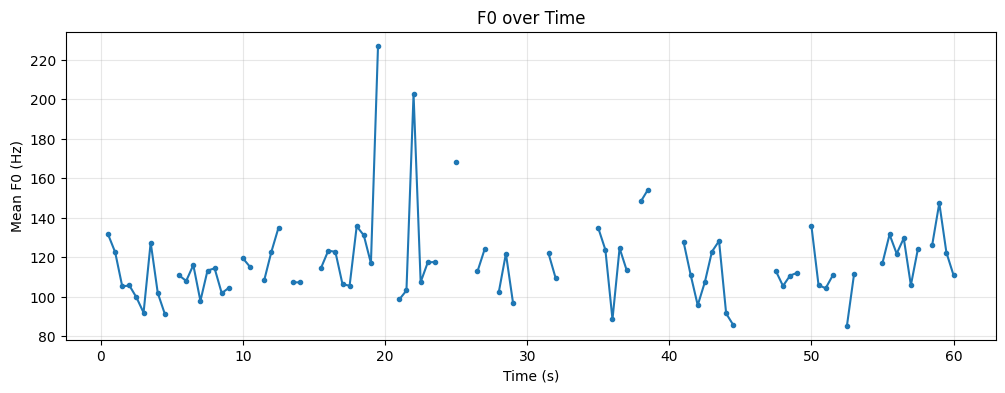

In [23]:
# 6.8 Visualize F0 over time

plt.figure(figsize=(12, 4))

plt.plot(
    aligned_df["start"],
    aligned_df["f0_mean"],
    marker="o",
    markersize=3
)

plt.xlabel("Time (s)")
plt.ylabel("Mean F0 (Hz)")
plt.title("F0 over Time")

plt.grid(True, alpha=0.3)

plt.show()

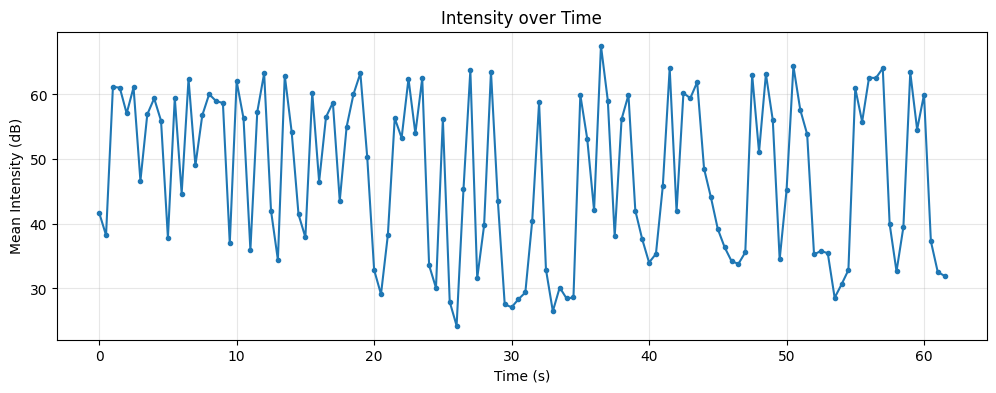

In [24]:
# 6.9 Visualize intensity over time

plt.figure(figsize=(12, 4))

plt.plot(
    aligned_df["start"],
    aligned_df["intensity_mean"],
    marker="o",
    markersize=3
)

plt.xlabel("Time (s)")
plt.ylabel("Mean Intensity (dB)")
plt.title("Intensity over Time")

plt.grid(True, alpha=0.3)

plt.show()

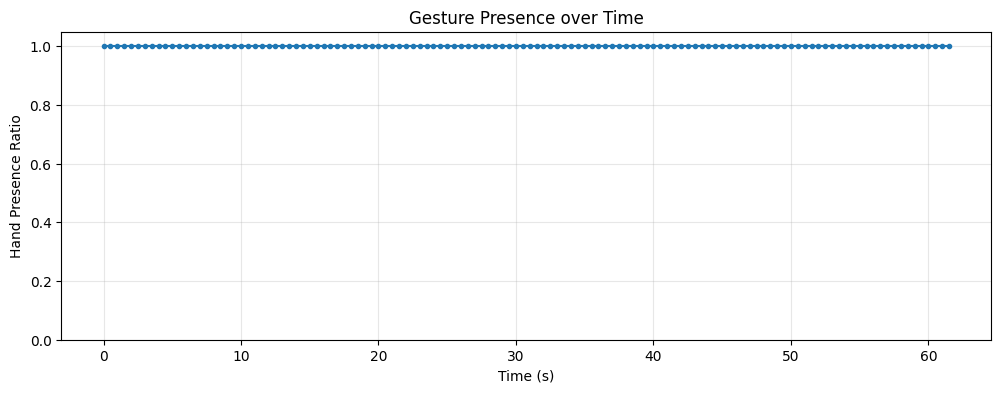

In [25]:
# 6.10 Visualize gesture presence over time

plt.figure(figsize=(12, 4))

plt.plot(
    aligned_df["start"],
    aligned_df["hand_presence_ratio"],
    marker="o",
    markersize=3
)

plt.xlabel("Time (s)")
plt.ylabel("Hand Presence Ratio")
plt.title("Gesture Presence over Time")

plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

plt.show()

In [26]:
# 6.11 Calculate wrist movement

wrist = {}

for r in results:
    if r["hands"]:
        # Use the first detected hand
        p = r["hands"][0][0]

        wrist[r["frame"]] = (
            p["x"],
            p["y"]
        )

# Calculate wrist speed
speeds = np.full(len(results), np.nan)

for f in range(1, len(results)):

    if f in wrist and (f - 1) in wrist:

        dx = wrist[f][0] - wrist[f - 1][0]
        dy = wrist[f][1] - wrist[f - 1][1]

        speeds[f] = np.hypot(dx, dy) * fps

# Smooth the signal
speeds_s = (
    pd.Series(speeds)
    .rolling(5, min_periods=1, center=True)
    .mean()
    .values
)

print("Wrist movement calculated!")

print("Number of frames:", len(speeds_s))
print("Mean wrist speed:", np.nanmean(speeds_s))
print("Maximum wrist speed:", np.nanmax(speeds_s))

Wrist movement calculated!
Number of frames: 1846
Mean wrist speed: 0.18213913089868683
Maximum wrist speed: 5.5137995176497325


In [33]:
# 6.12 Align Wrist Movement with ASR Chunks

import numpy as np
import pandas as pd

print("===================================")
print("6.12 WRIST–SPEECH ALIGNMENT")
print("===================================")

# 1. Basic information

print("FPS:", fps)
print("Number of wrist movement frames:", len(speeds_s))
print("Number of ASR chunks:", len(asr_result["chunks"]))


# 2. Align wrist movement with each ASR chunk

aligned_gesture = []

for chunk in asr_result["chunks"]:

    # Get ASR timestamp and text
    start_time, end_time = chunk["timestamp"]
    text = chunk["text"]

    # Convert time (seconds) to video frame indices
    start_frame = int(start_time * fps)
    end_frame = int(end_time * fps)

    # Keep frame indices within valid range
    start_frame = max(0, start_frame)
    end_frame = min(len(speeds_s), end_frame)

    # Extract wrist movement for this speech segment
    segment_speed = speeds_s[start_frame:end_frame]


    # Calculate gesture features

    if len(segment_speed) > 0 and not np.all(np.isnan(segment_speed)):

        mean_speed = np.nanmean(segment_speed)
        max_speed = np.nanmax(segment_speed)
        std_speed = np.nanstd(segment_speed)
        movement_energy = np.nanmean(segment_speed ** 2)

    else:

        mean_speed = np.nan
        max_speed = np.nan
        std_speed = np.nan
        movement_energy = np.nan


    # Save aligned result

    aligned_gesture.append({
        "start": start_time,
        "end": end_time,
        "text": text,
        "mean_wrist_speed": mean_speed,
        "max_wrist_speed": max_speed,
        "std_wrist_speed": std_speed,
        "movement_energy": movement_energy
    })



# 3. Convert to DataFrame

gesture_df = pd.DataFrame(aligned_gesture)


# 4. Display results

print("-----------------------------------")
print("Aligned gesture features:")
print("-----------------------------------")

display(gesture_df)

6.12 WRIST–SPEECH ALIGNMENT
FPS: 30.0
Number of wrist movement frames: 1846
Number of ASR chunks: 10
-----------------------------------
Aligned gesture features:
-----------------------------------


,start,end,text,mean_wrist_speed,max_wrist_speed,std_wrist_speed,movement_energy
0,0.0,5.0,我和发小可以说是从小穿一条裤子长大的吧,0.504861,3.909186,0.663503,0.695121
1,5.0,11.0,但是长大之后我还在上学他已经去外地工作了,0.262130,4.565351,0.708201,0.570261
2,11.0,15.0,我们很长时间没有见面,0.076757,0.427375,0.069739,0.010755
3,15.0,20.0,但是我的假期时间是比较充裕的,0.053016,0.223570,0.047776,0.005093
4,20.0,29.0,我便从兰州去到苏州找他相聚,0.106230,0.649835,0.094715,0.020256
5,29.0,44.0,这一路上见证了从西北的辽阔到江南的秀起,0.054405,0.244923,0.040691,0.004616
6,44.0,52.0,正好体验了一次江南的好风光,0.350397,2.416134,0.377547,0.265320
7,52.0,57.0,我就只能说这次旅行,0.126884,0.402379,0.094504,0.025031
8,57.0,58.0,举行,0.016465,0.023188,0.003359,0.000282
9,59.0,61.0,真的很开心,0.640436,5.513800,1.314482,2.138021


6.13 WRIST–SPEECH ALIGNMENT CHECK


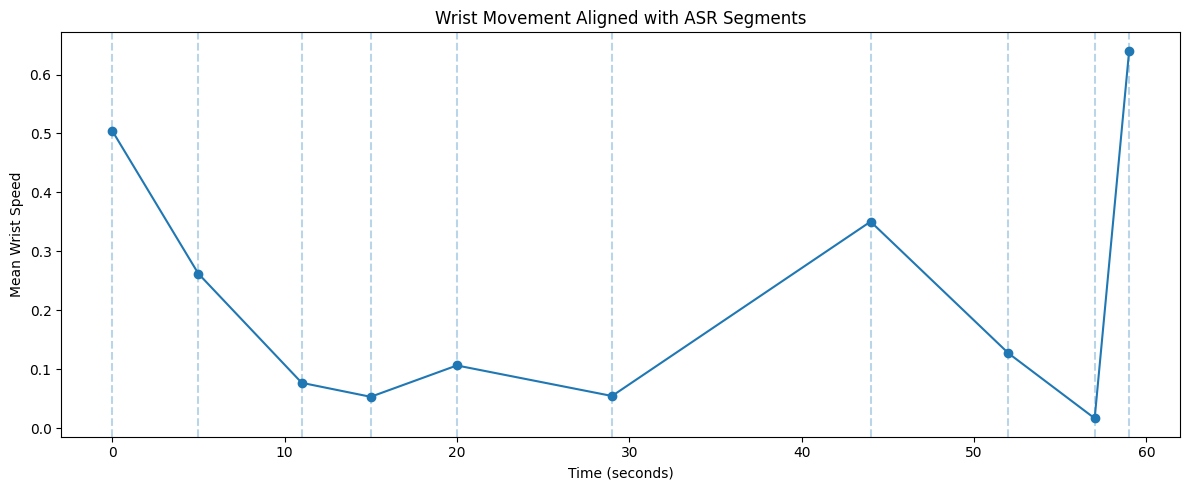

-----------------------------------
Gesture alignment summary:
-----------------------------------


,start,end,text,mean_wrist_speed,max_wrist_speed,std_wrist_speed,movement_energy
0,0.0,5.0,我和发小可以说是从小穿一条裤子长大的吧,0.504861,3.909186,0.663503,0.695121
1,5.0,11.0,但是长大之后我还在上学他已经去外地工作了,0.262130,4.565351,0.708201,0.570261
2,11.0,15.0,我们很长时间没有见面,0.076757,0.427375,0.069739,0.010755
3,15.0,20.0,但是我的假期时间是比较充裕的,0.053016,0.223570,0.047776,0.005093
4,20.0,29.0,我便从兰州去到苏州找他相聚,0.106230,0.649835,0.094715,0.020256
5,29.0,44.0,这一路上见证了从西北的辽阔到江南的秀起,0.054405,0.244923,0.040691,0.004616
6,44.0,52.0,正好体验了一次江南的好风光,0.350397,2.416134,0.377547,0.265320
7,52.0,57.0,我就只能说这次旅行,0.126884,0.402379,0.094504,0.025031
8,57.0,58.0,举行,0.016465,0.023188,0.003359,0.000282
9,59.0,61.0,真的很开心,0.640436,5.513800,1.314482,2.138021


In [34]:
# 6.13 Visualize Wrist Movement Aligned with Speech

import matplotlib.pyplot as plt

print("===================================")
print("6.13 WRIST–SPEECH ALIGNMENT CHECK")
print("===================================")

# 1. Plot mean wrist speed for each ASR chunk

x = gesture_df["start"]
y = gesture_df["mean_wrist_speed"]

plt.figure(figsize=(12, 5))

plt.plot(
    x,
    y,
    marker="o"
)

# Add ASR chunk boundaries
for t in gesture_df["start"]:
    plt.axvline(
        x=t,
        linestyle="--",
        alpha=0.3
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Mean Wrist Speed")
plt.title("Wrist Movement Aligned with ASR Segments")

plt.tight_layout()
plt.show()


# 2. Display the aligned table

print("-----------------------------------")
print("Gesture alignment summary:")
print("-----------------------------------")

display(
    gesture_df[
        [
            "start",
            "end",
            "text",
            "mean_wrist_speed",
            "max_wrist_speed",
            "std_wrist_speed",
            "movement_energy"
        ]
    ]
)

In [35]:
# 6.14 Find Prosody Feature Variables

print("Possible prosody-related variables:")
print("-----------------------------------")

prosody_keywords = [
    "prosody",
    "pitch",
    "f0",
    "energy",
    "intensity",
    "speech",
    "feature"
]

for name in list(globals().keys()):

    name_lower = name.lower()

    if any(keyword in name_lower for keyword in prosody_keywords):

        value = globals()[name]

        try:
            length = len(value)
        except Exception:
            length = "N/A"

        print(
            f"{name} | "
            f"type={type(value).__name__} | "
            f"length={length}"
        )

Possible prosody-related variables:
-----------------------------------
pitch | type=Pitch | length=6154
intensity | type=ndarray | length=7690
prosody | type=dict | length=3
f0 | type=ndarray | length=6154
f0_fps | type=float | length=N/A
intensity_fps | type=float | length=N/A
prosody_aligned | type=list | length=124
f0_start | type=int | length=N/A
f0_end | type=int | length=N/A
intensity_start | type=int | length=N/A
intensity_end | type=int | length=N/A
f0_window | type=ndarray | length=8
intensity_window | type=ndarray | length=10
f0_valid | type=ndarray | length=0
movement_energy | type=float64 | length=N/A
prosody_keywords | type=list | length=7


In [36]:
# 6.15 Inspect Prosody Alignment Structure

print("===================================")
print("6.15 PROSODY STRUCTURE CHECK")
print("===================================")

print("Type:", type(prosody_aligned).__name__)
print("Number of entries:", len(prosody_aligned))

print("\nFirst 5 entries:")
print("-----------------------------------")

for i, item in enumerate(prosody_aligned[:5]):
    print(f"\nEntry {i}:")
    print(item)

6.15 PROSODY STRUCTURE CHECK
Type: list
Number of entries: 124

First 5 entries:
-----------------------------------

Entry 0:
{'start': 0.0, 'end': 0.5, 'f0_mean': nan, 'intensity_mean': 41.702774152292875}

Entry 1:
{'start': 0.5, 'end': 1.0, 'f0_mean': 131.6158379590392, 'intensity_mean': 38.23897940512406}

Entry 2:
{'start': 1.0, 'end': 1.5, 'f0_mean': 122.57195328592086, 'intensity_mean': 61.18813729890756}

Entry 3:
{'start': 1.5, 'end': 2.0, 'f0_mean': 105.23945948572504, 'intensity_mean': 61.0416631149655}

Entry 4:
{'start': 2.0, 'end': 2.5, 'f0_mean': 105.72084784425142, 'intensity_mean': 57.05999866265855}


In [37]:
# 6.16 Aggregate Prosody Features to ASR Chunks

import numpy as np
import pandas as pd

print("===================================")
print("6.16 PROSODY–SPEECH ALIGNMENT")
print("===================================")


# 1. Get ASR chunks

asr_chunks = asr_result["chunks"]

print("Number of ASR chunks:", len(asr_chunks))
print("Number of prosody windows:", len(prosody_aligned))


# 2. Aggregate prosody for each ASR chunk

aligned_prosody = []

for chunk_id, chunk in enumerate(asr_chunks):

    start_time, end_time = chunk["timestamp"]
    text = chunk["text"]

    # Select prosody windows that fall inside this ASR segment
    segment_prosody = [
        p for p in prosody_aligned
        if p["start"] >= start_time
        and p["end"] <= end_time
    ]

    # Extract F0 and intensity
    f0_values = np.array(
        [p["f0_mean"] for p in segment_prosody],
        dtype=float
    )

    intensity_values = np.array(
        [p["intensity_mean"] for p in segment_prosody],
        dtype=float
    )

    # F0 statistics

    if len(f0_values) > 0 and not np.all(np.isnan(f0_values)):

        f0_mean = np.nanmean(f0_values)
        f0_std = np.nanstd(f0_values)
        f0_min = np.nanmin(f0_values)
        f0_max = np.nanmax(f0_values)

    else:

        f0_mean = np.nan
        f0_std = np.nan
        f0_min = np.nan
        f0_max = np.nan


    # Intensity statistics

    if len(intensity_values) > 0 and not np.all(np.isnan(intensity_values)):

        intensity_mean = np.nanmean(intensity_values)
        intensity_std = np.nanstd(intensity_values)
        intensity_min = np.nanmin(intensity_values)
        intensity_max = np.nanmax(intensity_values)

    else:

        intensity_mean = np.nan
        intensity_std = np.nan
        intensity_min = np.nan
        intensity_max = np.nan


    # Save aligned prosody features

    aligned_prosody.append({
        "chunk_id": chunk_id,
        "start": start_time,
        "end": end_time,
        "text": text,

        "f0_mean": f0_mean,
        "f0_std": f0_std,
        "f0_min": f0_min,
        "f0_max": f0_max,

        "intensity_mean": intensity_mean,
        "intensity_std": intensity_std,
        "intensity_min": intensity_min,
        "intensity_max": intensity_max,

        "num_prosody_windows": len(segment_prosody)
    })


# 3. Convert to DataFrame

prosody_df = pd.DataFrame(aligned_prosody)


# 4. Display result

print("-----------------------------------")
print("Aggregated prosody features:")
print("-----------------------------------")

display(prosody_df)

6.16 PROSODY–SPEECH ALIGNMENT
Number of ASR chunks: 10
Number of prosody windows: 124
-----------------------------------
Aggregated prosody features:
-----------------------------------


,chunk_id,start,end,text,f0_mean,f0_std,f0_min,f0_max,intensity_mean,intensity_std,intensity_min,intensity_max,num_prosody_windows
0,0,0.0,5.0,我和发小可以说是从小穿一条裤子长大的吧,108.589312,14.165170,91.209544,131.615838,53.921923,8.098572,38.238979,61.188137,10
1,1,5.0,11.0,但是长大之后我还在上学他已经去外地工作了,110.128935,6.550569,97.896197,119.406515,53.603180,8.763805,36.985377,62.410562,12
2,2,11.0,15.0,我们很长时间没有见面,116.249523,11.101804,107.286482,135.073360,48.949632,11.076581,34.415898,63.261811,8
3,3,15.0,20.0,但是我的假期时间是比较充裕的,131.527226,35.115296,105.592289,227.118499,53.211210,7.896917,37.904290,63.287384,10
4,4,20.0,29.0,我便从兰州去到苏州找他相聚,125.118755,30.398384,98.673112,202.610754,44.709037,13.810503,24.238829,63.727192,18
5,5,29.0,44.0,这一路上见证了从西北的辽阔到江南的秀起,119.332129,17.446365,88.550018,154.278142,44.001655,13.361609,26.479012,67.537640,30
6,6,44.0,52.0,正好体验了一次江南的好风光,107.555148,12.751197,85.703175,135.882324,47.534850,10.853686,33.800277,64.373717,16
7,7,52.0,57.0,我就只能说这次旅行,116.131781,15.406048,85.338238,131.548780,44.041188,13.688205,28.560234,62.596407,10
8,8,57.0,58.0,举行,115.117065,9.286932,105.830133,124.403997,52.014192,12.037206,39.976986,64.051398,2
9,9,59.0,61.0,真的很开心,126.936431,15.219028,110.981026,147.424010,53.818581,10.045912,37.295089,63.409819,4


In [38]:
# 6.17 Merge Text + Prosody + Gesture

print("===================================")
print("6.17 MULTIMODAL FEATURE MERGE")
print("===================================")


# 1. Merge prosody and gesture features

multimodal_df = pd.merge(
    prosody_df,
    gesture_df[
        [
            "start",
            "end",
            "mean_wrist_speed",
            "max_wrist_speed",
            "std_wrist_speed",
            "movement_energy"
        ]
    ],
    on=["start", "end"],
    how="inner"
)


# 2. Check merge result

print("Number of multimodal segments:", len(multimodal_df))
print("Number of columns:", len(multimodal_df.columns))

print("\nColumns:")
print(multimodal_df.columns.tolist())


# 3. Display final multimodal dataset

print("\n-----------------------------------")
print("MULTIMODAL ALIGNED DATA")
print("-----------------------------------")

display(multimodal_df)

6.17 MULTIMODAL FEATURE MERGE
Number of multimodal segments: 10
Number of columns: 17

Columns:
['chunk_id', 'start', 'end', 'text', 'f0_mean', 'f0_std', 'f0_min', 'f0_max', 'intensity_mean', 'intensity_std', 'intensity_min', 'intensity_max', 'num_prosody_windows', 'mean_wrist_speed', 'max_wrist_speed', 'std_wrist_speed', 'movement_energy']

-----------------------------------
MULTIMODAL ALIGNED DATA
-----------------------------------


,chunk_id,start,end,text,f0_mean,f0_std,f0_min,f0_max,intensity_mean,intensity_std,intensity_min,intensity_max,num_prosody_windows,mean_wrist_speed,max_wrist_speed,std_wrist_speed,movement_energy
0,0,0.0,5.0,我和发小可以说是从小穿一条裤子长大的吧,108.589312,14.165170,91.209544,131.615838,53.921923,8.098572,38.238979,61.188137,10,0.504861,3.909186,0.663503,0.695121
1,1,5.0,11.0,但是长大之后我还在上学他已经去外地工作了,110.128935,6.550569,97.896197,119.406515,53.603180,8.763805,36.985377,62.410562,12,0.262130,4.565351,0.708201,0.570261
2,2,11.0,15.0,我们很长时间没有见面,116.249523,11.101804,107.286482,135.073360,48.949632,11.076581,34.415898,63.261811,8,0.076757,0.427375,0.069739,0.010755
3,3,15.0,20.0,但是我的假期时间是比较充裕的,131.527226,35.115296,105.592289,227.118499,53.211210,7.896917,37.904290,63.287384,10,0.053016,0.223570,0.047776,0.005093
4,4,20.0,29.0,我便从兰州去到苏州找他相聚,125.118755,30.398384,98.673112,202.610754,44.709037,13.810503,24.238829,63.727192,18,0.106230,0.649835,0.094715,0.020256
5,5,29.0,44.0,这一路上见证了从西北的辽阔到江南的秀起,119.332129,17.446365,88.550018,154.278142,44.001655,13.361609,26.479012,67.537640,30,0.054405,0.244923,0.040691,0.004616
6,6,44.0,52.0,正好体验了一次江南的好风光,107.555148,12.751197,85.703175,135.882324,47.534850,10.853686,33.800277,64.373717,16,0.350397,2.416134,0.377547,0.265320
7,7,52.0,57.0,我就只能说这次旅行,116.131781,15.406048,85.338238,131.548780,44.041188,13.688205,28.560234,62.596407,10,0.126884,0.402379,0.094504,0.025031
8,8,57.0,58.0,举行,115.117065,9.286932,105.830133,124.403997,52.014192,12.037206,39.976986,64.051398,2,0.016465,0.023188,0.003359,0.000282
9,9,59.0,61.0,真的很开心,126.936431,15.219028,110.981026,147.424010,53.818581,10.045912,37.295089,63.409819,4,0.640436,5.513800,1.314482,2.138021


In [39]:
# 6.18 Data Quality Check & Save

print("===================================")
print("6.18 DATA QUALITY CHECK")
print("===================================")


# 1. Basic dataset information

print("Number of rows:", len(multimodal_df))
print("Number of columns:", len(multimodal_df.columns))

print("\nData types:")
print(multimodal_df.dtypes)


# 2. Check missing values

print("\n-----------------------------------")
print("Missing values:")
print("-----------------------------------")

missing_values = multimodal_df.isna().sum()

display(
    missing_values[missing_values > 0]
)


# 3. Check duplicated segments

print("\n-----------------------------------")
print("Duplicate time segments:")
print("-----------------------------------")

duplicate_segments = multimodal_df.duplicated(
    subset=["start", "end"]
).sum()

print("Number of duplicated segments:", duplicate_segments)


# 4. Check time alignment

print("\n-----------------------------------")
print("Time alignment check:")
print("-----------------------------------")

time_check = (
    multimodal_df["end"] > multimodal_df["start"]
).all()

print("All end times > start times:", time_check)


# 5. Check text

print("\n-----------------------------------")
print("Text check:")
print("-----------------------------------")

empty_text = multimodal_df["text"].isna().sum()

print("Empty / missing text:", empty_text)
print(
    "Average text length:",
    multimodal_df["text"].str.len().mean()
)


# 6. Show summary

print("\n===================================")
print("DATA QUALITY SUMMARY")
print("===================================")

print("Rows:", len(multimodal_df))
print("Columns:", len(multimodal_df.columns))
print("Duplicate segments:", duplicate_segments)
print("Invalid time intervals:", not time_check)
print("Missing text:", empty_text)


# 7. Save dataset

output_file = "multimodal_aligned_segments.csv"

multimodal_df.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("\n===================================")
print("DATASET SAVED")
print("===================================")

print("File:", output_file)
print("Rows:", len(multimodal_df))
print("Columns:", len(multimodal_df.columns))

6.18 DATA QUALITY CHECK
Number of rows: 10
Number of columns: 17

Data types:
chunk_id                 int64
start                  float64
end                    float64
text                    object
f0_mean                float64
f0_std                 float64
f0_min                 float64
f0_max                 float64
intensity_mean         float64
intensity_std          float64
intensity_min          float64
intensity_max          float64
num_prosody_windows      int64
mean_wrist_speed       float64
max_wrist_speed        float64
std_wrist_speed        float64
movement_energy        float64
dtype: object

-----------------------------------
Missing values:
-----------------------------------


,0



-----------------------------------
Duplicate time segments:
-----------------------------------
Number of duplicated segments: 0

-----------------------------------
Time alignment check:
-----------------------------------
All end times > start times: True

-----------------------------------
Text check:
-----------------------------------
Empty / missing text: 0
Average text length: 12.4

DATA QUALITY SUMMARY
Rows: 10
Columns: 17
Duplicate segments: 0
Invalid time intervals: False
Missing text: 0

DATASET SAVED
File: multimodal_aligned_segments.csv
Rows: 10
Columns: 17


In [40]:
# 6.19 Feature Quality Check

print("===================================")
print("6.19 FEATURE QUALITY CHECK")
print("===================================")


# 1. Select numerical multimodal features

feature_columns = [
    "f0_mean",
    "f0_std",
    "f0_min",
    "f0_max",
    "intensity_mean",
    "intensity_std",
    "intensity_min",
    "intensity_max",
    "mean_wrist_speed",
    "max_wrist_speed",
    "std_wrist_speed",
    "movement_energy"
]

# 2. Descriptive statistics

print("-----------------------------------")
print("Descriptive statistics:")
print("-----------------------------------")

display(
    multimodal_df[feature_columns].describe().T
)


# 3. Check negative values

print("-----------------------------------")
print("Negative-value check:")
print("-----------------------------------")

for column in feature_columns:

    negative_count = (
        multimodal_df[column] < 0
    ).sum()

    print(
        f"{column}: {negative_count} negative values"
    )


# 4. Check zero values

print("-----------------------------------")
print("Zero-value check:")
print("-----------------------------------")

for column in feature_columns:

    zero_count = (
        multimodal_df[column] == 0
    ).sum()

    print(
        f"{column}: {zero_count} zero values"
    )


# 5. Check finite values

print("-----------------------------------")
print("Finite-value check:")
print("-----------------------------------")

for column in feature_columns:

    finite_count = np.isfinite(
        multimodal_df[column]
    ).sum()

    print(
        f"{column}: "
        f"{finite_count}/{len(multimodal_df)} finite values"
    )


print("===================================")
print("6.19 CHECK COMPLETE")
print("===================================")

6.19 FEATURE QUALITY CHECK
-----------------------------------
Descriptive statistics:
-----------------------------------


,count,mean,std,min,25%,50%,75%,max
f0_mean,10.0,117.668631,8.087536,107.555148,111.375967,116.190652,123.672099,131.527226
f0_std,10.0,16.744079,9.082931,6.550569,11.514153,14.692099,16.936285,35.115296
f0_min,10.0,97.706022,9.546633,85.338238,89.214899,98.284654,105.770672,110.981026
f0_max,10.0,150.936222,35.626118,119.406515,131.565545,135.477842,152.564609,227.118499
intensity_mean,10.0,49.580545,4.245487,44.001655,45.415490,50.481912,53.505188,53.921923
intensity_std,10.0,10.963300,2.254636,7.896917,9.084331,10.965133,13.030508,13.810503
intensity_min,10.0,33.789497,5.476347,24.238829,29.870245,35.700637,37.751990,39.976986
intensity_max,10.0,63.584407,1.660270,61.188137,62.762758,63.348601,63.970347,67.537640
mean_wrist_speed,10.0,0.219158,0.214877,0.016465,0.059993,0.116557,0.328330,0.640436
max_wrist_speed,10.0,1.837574,2.094289,0.023188,0.284287,0.538605,3.535923,5.513800


-----------------------------------
Negative-value check:
-----------------------------------
f0_mean: 0 negative values
f0_std: 0 negative values
f0_min: 0 negative values
f0_max: 0 negative values
intensity_mean: 0 negative values
intensity_std: 0 negative values
intensity_min: 0 negative values
intensity_max: 0 negative values
mean_wrist_speed: 0 negative values
max_wrist_speed: 0 negative values
std_wrist_speed: 0 negative values
movement_energy: 0 negative values
-----------------------------------
Zero-value check:
-----------------------------------
f0_mean: 0 zero values
f0_std: 0 zero values
f0_min: 0 zero values
f0_max: 0 zero values
intensity_mean: 0 zero values
intensity_std: 0 zero values
intensity_min: 0 zero values
intensity_max: 0 zero values
mean_wrist_speed: 0 zero values
max_wrist_speed: 0 zero values
std_wrist_speed: 0 zero values
movement_energy: 0 zero values
-----------------------------------
Finite-value check:
-----------------------------------
f0_mean: 10/10

In [41]:
# 6.20 Feature Normalization

from sklearn.preprocessing import StandardScaler

print("===================================")
print("6.20 FEATURE NORMALIZATION")
print("===================================")


# 1. Select numerical multimodal features

feature_columns = [
    "f0_mean",
    "f0_std",
    "f0_min",
    "f0_max",
    "intensity_mean",
    "intensity_std",
    "intensity_min",
    "intensity_max",
    "mean_wrist_speed",
    "max_wrist_speed",
    "std_wrist_speed",
    "movement_energy"
]


# 2. Create a copy of the original dataset

multimodal_normalized_df = multimodal_df.copy()


# 3. Standardize numerical features

scaler = StandardScaler()

multimodal_normalized_df[feature_columns] = scaler.fit_transform(
    multimodal_df[feature_columns]
)


# 4. Display normalized features

print("-----------------------------------")
print("Normalized multimodal features:")
print("-----------------------------------")

display(
    multimodal_normalized_df[
        [
            "chunk_id",
            "start",
            "end",
            "text"
        ] + feature_columns
    ]
)


# 5. Check normalization

print("-----------------------------------")
print("Normalization check:")
print("-----------------------------------")

normalization_check = (
    multimodal_normalized_df[feature_columns]
    .agg(["mean", "std"])
    .T
)

display(normalization_check)


print("===================================")
print("6.20 NORMALIZATION COMPLETE")
print("===================================")

6.20 FEATURE NORMALIZATION
-----------------------------------
Normalized multimodal features:
-----------------------------------


,chunk_id,start,end,text,f0_mean,f0_std,f0_min,f0_max,intensity_mean,intensity_std,intensity_min,intensity_max,mean_wrist_speed,max_wrist_speed,std_wrist_speed,movement_energy
0,0,0.0,5.0,我和发小可以说是从小穿一条裤子长大的吧,-1.183357,-0.299288,-0.717309,-0.571644,1.077901,-1.339324,0.856441,-1.521373,1.401536,1.042679,0.787364,0.505025
1,1,5.0,11.0,但是长大之后我还在上学他已经去外地工作了,-0.982690,-1.182977,0.020998,-0.932889,0.998762,-1.028313,0.615146,-0.745265,0.210800,1.372938,0.896644,0.308979
2,2,11.0,15.0,我们很长时间没有见面,-0.184960,-0.654797,1.057828,-0.469345,-0.156647,0.052961,0.120570,-0.204813,-0.698558,-0.709778,-0.664294,-0.569519
3,3,15.0,20.0,但是我的假期时间是比较充裕的,1.806266,2.132017,0.870763,2.254053,0.901441,-1.433602,0.792019,-0.188578,-0.815019,-0.812357,-0.717990,-0.578409
4,4,20.0,29.0,我便从兰州去到苏州找他相聚,0.971015,1.584610,0.106781,1.528927,-1.209524,1.331131,-1.838322,0.090653,-0.553979,-0.597810,-0.603231,-0.554602
5,5,29.0,44.0,这一路上见证了从西北的辽阔到江南的秀起,0.216813,0.081502,-1.010961,0.098880,-1.385157,1.121263,-1.407129,2.509877,-0.808208,-0.801609,-0.735313,-0.579159
6,6,44.0,52.0,正好体验了一次江南的好风光,-1.318145,-0.463382,-1.325296,-0.445409,-0.507916,-0.051247,0.002075,0.501127,0.643802,0.291199,0.088246,-0.169819
7,7,52.0,57.0,我就只能说这次旅行,-0.200306,-0.155281,-1.365590,-0.573629,-1.375341,1.273954,-1.006534,-0.627273,-0.452658,-0.722359,-0.603747,-0.547105
8,8,57.0,58.0,举行,-0.332559,-0.865417,0.897025,-0.785026,0.604239,0.502075,1.190974,0.296489,-0.994323,-0.913212,-0.826583,-0.585962
9,9,59.0,61.0,真的很开心,1.207923,-0.176985,1.465761,-0.103918,1.052243,-0.428899,0.674760,-0.110845,2.066608,1.850309,2.378904,2.770569


-----------------------------------
Normalization check:
-----------------------------------


,mean,std
f0_mean,-2.042810e-15,1.054093
f0_std,1.582068e-16,1.054093
f0_min,1.776357e-16,1.054093
f0_max,-8.465451e-17,1.054093
intensity_mean,-1.554312e-16,1.054093
intensity_std,-3.053113e-16,1.054093
intensity_min,5.662137e-16,1.054093
intensity_max,1.418310e-15,1.054093
mean_wrist_speed,-4.440892e-17,1.054093
max_wrist_speed,-2.220446e-17,1.054093


6.20 NORMALIZATION COMPLETE


In [42]:
# 6.21 Final Dataset Export

print("===================================")
print("6.21 FINAL DATASET EXPORT")
print("===================================")


# 1. Save original multimodal dataset

original_file = "multimodal_aligned_segments.csv"

multimodal_df.to_csv(
    original_file,
    index=False,
    encoding="utf-8-sig"
)

print("Original dataset saved:")
print(
    f"  {original_file} "
    f"({len(multimodal_df)} rows × {len(multimodal_df.columns)} columns)"
)


# 2. Save normalized multimodal dataset

normalized_file = "multimodal_aligned_segments_normalized.csv"

multimodal_normalized_df.to_csv(
    normalized_file,
    index=False,
    encoding="utf-8-sig"
)

print("Normalized dataset saved:")
print(
    f"  {normalized_file} "
    f"({len(multimodal_normalized_df)} rows × "
    f"{len(multimodal_normalized_df.columns)} columns)"
)


# 3. Verify files by reading them back

original_check = pd.read_csv(
    original_file,
    encoding="utf-8-sig"
)

normalized_check = pd.read_csv(
    normalized_file,
    encoding="utf-8-sig"
)


# 4. Final verification

print("-----------------------------------")
print("EXPORT VERIFICATION")
print("-----------------------------------")

print(
    "Original:",
    original_check.shape,
    "✅"
)

print(
    "Normalized:",
    normalized_check.shape,
    "✅"
)

print(
    "Original columns preserved:",
    list(original_check.columns) == list(multimodal_df.columns)
)

print(
    "Normalized columns preserved:",
    list(normalized_check.columns) == list(multimodal_normalized_df.columns)
)


print("===================================")
print("6.21 EXPORT COMPLETE")
print("===================================")

6.21 FINAL DATASET EXPORT
Original dataset saved:
  multimodal_aligned_segments.csv (10 rows × 17 columns)
Normalized dataset saved:
  multimodal_aligned_segments_normalized.csv (10 rows × 17 columns)
-----------------------------------
EXPORT VERIFICATION
-----------------------------------
Original: (10, 17) ✅
Normalized: (10, 17) ✅
Original columns preserved: True
Normalized columns preserved: True
6.21 EXPORT COMPLETE


6.22 MULTIMODAL VISUALIZATION


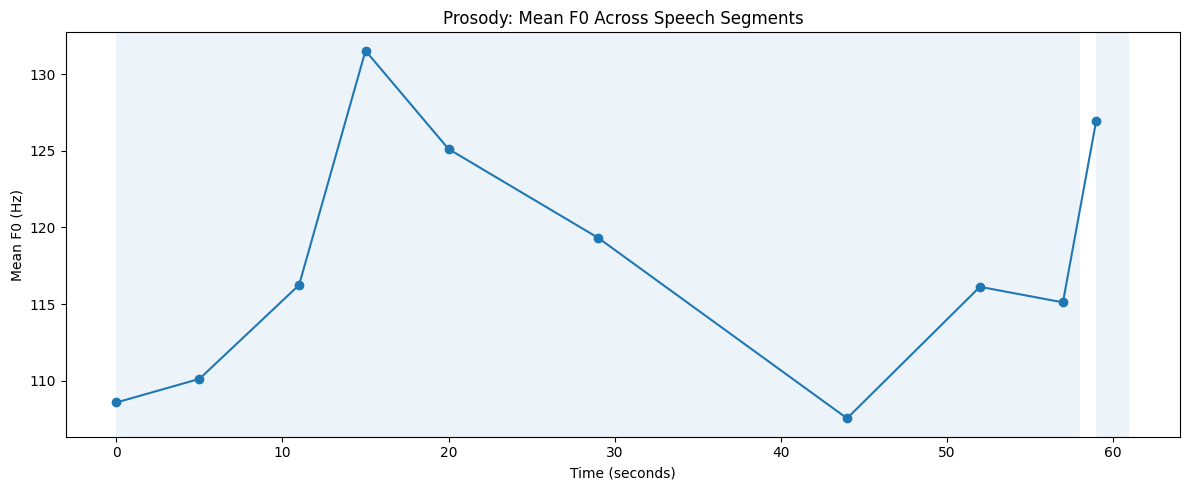

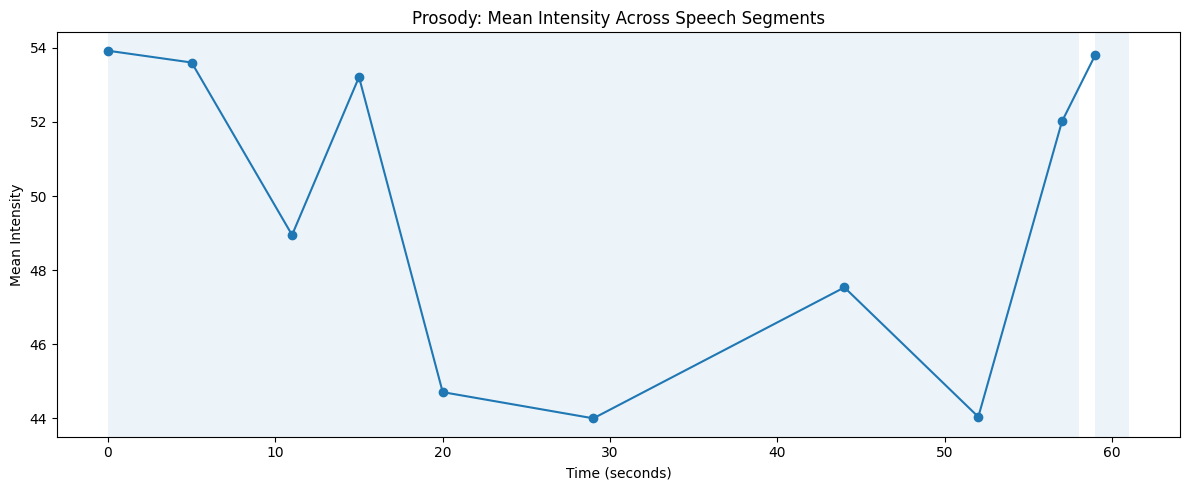

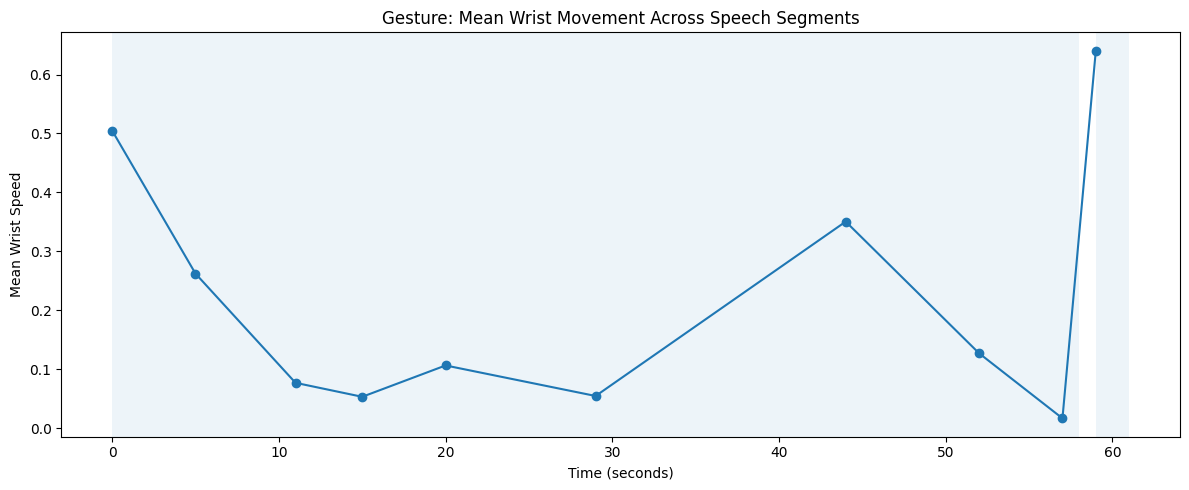

6.22 VISUALIZATION COMPLETE


In [43]:
# 6.22 Multimodal Visualization

import matplotlib.pyplot as plt

print("===================================")
print("6.22 MULTIMODAL VISUALIZATION")
print("===================================")


# 1. F0 contour by ASR segment

plt.figure(figsize=(12, 5))

plt.plot(
    multimodal_df["start"],
    multimodal_df["f0_mean"],
    marker="o"
)

for _, row in multimodal_df.iterrows():
    plt.axvspan(
        row["start"],
        row["end"],
        alpha=0.08
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Mean F0 (Hz)")
plt.title("Prosody: Mean F0 Across Speech Segments")

plt.tight_layout()
plt.show()


# 2. Intensity by ASR segment

plt.figure(figsize=(12, 5))

plt.plot(
    multimodal_df["start"],
    multimodal_df["intensity_mean"],
    marker="o"
)

for _, row in multimodal_df.iterrows():
    plt.axvspan(
        row["start"],
        row["end"],
        alpha=0.08
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Mean Intensity")
plt.title("Prosody: Mean Intensity Across Speech Segments")

plt.tight_layout()
plt.show()


# 3. Wrist movement by ASR segment

plt.figure(figsize=(12, 5))

plt.plot(
    multimodal_df["start"],
    multimodal_df["mean_wrist_speed"],
    marker="o"
)

for _, row in multimodal_df.iterrows():
    plt.axvspan(
        row["start"],
        row["end"],
        alpha=0.08
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Mean Wrist Speed")
plt.title("Gesture: Mean Wrist Movement Across Speech Segments")

plt.tight_layout()
plt.show()


print("===================================")
print("6.22 VISUALIZATION COMPLETE")
print("===================================")

In [44]:
# 6.23 End-to-End Demo Summary

print("===================================")
print("6.23 END-TO-END DEMO SUMMARY")
print("===================================")


# 1. Pipeline summary

print("\n[1] INPUT")
print("-----------------------------------")
print("Video FPS:", fps)
print("Number of video frames:", len(results))


print("\n[2] ASR")
print("-----------------------------------")
print("Total transcript length:", len(asr_result["text"]))
print("Number of ASR chunks:", len(asr_result["chunks"]))


print("\n[3] PROSODY")
print("-----------------------------------")
print("Number of prosody windows:", len(prosody_aligned))
print("Prosody window size: 0.5 seconds")


print("\n[4] GESTURE")
print("-----------------------------------")
print("Number of wrist-movement frames:", len(speeds_s))
print("Mean wrist speed:", np.nanmean(speeds_s))
print("Maximum wrist speed:", np.nanmax(speeds_s))


print("\n[5] MULTIMODAL DATASET")
print("-----------------------------------")
print("Rows:", len(multimodal_df))
print("Columns:", len(multimodal_df.columns))


print("\nDataset columns:")
for i, column in enumerate(multimodal_df.columns, start=1):
    print(f"{i:02d}. {column}")


# 2. Final integrity checks

print("\n[6] INTEGRITY CHECK")
print("-----------------------------------")

print(
    "Missing values:",
    int(multimodal_df.isna().sum().sum())
)

print(
    "Duplicate segments:",
    int(
        multimodal_df.duplicated(
            subset=["start", "end"]
        ).sum()
    )
)

print(
    "Invalid time intervals:",
    int(
        (
            multimodal_df["end"]
            <= multimodal_df["start"]
        ).sum()
    )
)

print(
    "All numerical features finite:",
    bool(
        np.isfinite(
            multimodal_df[feature_columns]
        ).all().all()
    )
)


# 3. Final status

print("\n===================================")
print("PIPELINE STATUS")
print("===================================")

print("ASR extraction:              ✅")
print("Prosody extraction:          ✅")
print("Wrist movement extraction:   ✅")
print("Temporal alignment:          ✅")
print("Multimodal feature merge:    ✅")
print("Data quality check:          ✅")
print("Feature normalization:       ✅")
print("Dataset export:              ✅")
print("Visualization:               ✅")

print("\n===================================")
print("6.23 PIPELINE COMPLETE")
print("===================================")

6.23 END-TO-END DEMO SUMMARY

[1] INPUT
-----------------------------------
Video FPS: 30.0
Number of video frames: 1846

[2] ASR
-----------------------------------
Total transcript length: 124
Number of ASR chunks: 10

[3] PROSODY
-----------------------------------
Number of prosody windows: 124
Prosody window size: 0.5 seconds

[4] GESTURE
-----------------------------------
Number of wrist-movement frames: 1846
Mean wrist speed: 0.18213913089868683
Maximum wrist speed: 5.5137995176497325

[5] MULTIMODAL DATASET
-----------------------------------
Rows: 10
Columns: 17

Dataset columns:
01. chunk_id
02. start
03. end
04. text
05. f0_mean
06. f0_std
07. f0_min
08. f0_max
09. intensity_mean
10. intensity_std
11. intensity_min
12. intensity_max
13. num_prosody_windows
14. mean_wrist_speed
15. max_wrist_speed
16. std_wrist_speed
17. movement_energy

[6] INTEGRITY CHECK
-----------------------------------
Missing values: 0
Duplicate segments: 0
Invalid time intervals: 0
All numerical fea

7.1 TEMPORAL COORDINATION ANALYSIS
Number of temporal windows: 124


,start,end,f0_mean,intensity_mean,wrist_mean_speed,wrist_max_speed
0,0.0,0.5,NaN,41.702774,0.160160,0.468783
1,0.5,1.0,131.615838,38.238979,1.761382,3.909186
2,1.0,1.5,122.571953,61.188137,0.558217,0.720773
3,1.5,2.0,105.239459,61.041663,0.196810,0.379037
4,2.0,2.5,105.720848,57.059999,0.142270,0.221326



-----------------------------------
F0 ↔ Wrist Movement
-----------------------------------
Valid windows: 82
Pearson r: -0.09896946240986351
Pearson p: 0.3763602141953201
Spearman rho: -0.24151892121330854
Spearman p: 0.028819842395161485

-----------------------------------
Intensity ↔ Wrist Movement
-----------------------------------
Valid windows: 124
Pearson r: -0.05240828223131715
Pearson p: 0.5632094652408265
Spearman rho: 0.0026813532651455544
Spearman p: 0.9764212037555684


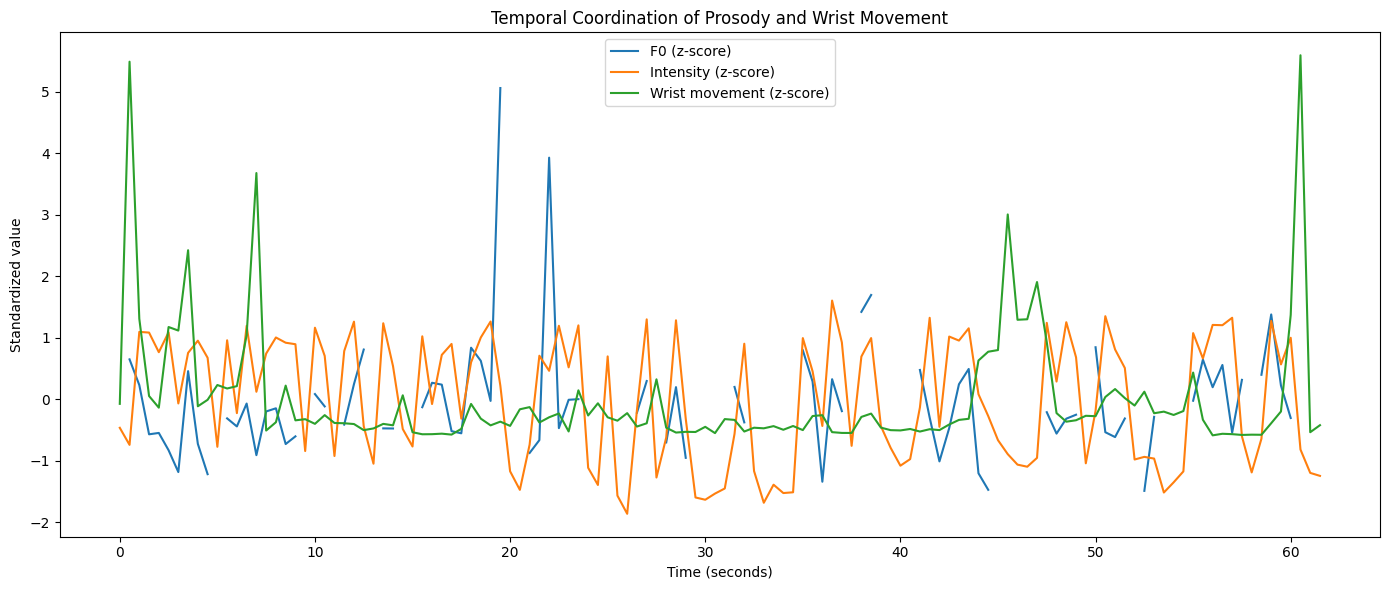


7.1 ANALYSIS COMPLETE


In [45]:
# 7.1 Temporal Coordination Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr

print("===================================")
print("7.1 TEMPORAL COORDINATION ANALYSIS")
print("===================================")


# 1. Create a temporal multimodal dataframe
#    Prosody: 0.5-second windows
#    Gesture: wrist movement mapped to the same windows

temporal_data = []

for p in prosody_aligned:

    start_time = p["start"]
    end_time = p["end"]

    # Convert time to video frames
    start_frame = int(start_time * fps)
    end_frame = min(
        int(end_time * fps),
        len(speeds_s)
    )

    # Wrist movement within the same time window
    segment_speed = speeds_s[start_frame:end_frame]

    if len(segment_speed) > 0 and not np.all(np.isnan(segment_speed)):
        wrist_mean_speed = np.nanmean(segment_speed)
        wrist_max_speed = np.nanmax(segment_speed)
    else:
        wrist_mean_speed = np.nan
        wrist_max_speed = np.nan

    temporal_data.append({
        "start": start_time,
        "end": end_time,
        "f0_mean": p["f0_mean"],
        "intensity_mean": p["intensity_mean"],
        "wrist_mean_speed": wrist_mean_speed,
        "wrist_max_speed": wrist_max_speed
    })


# 2. Create DataFrame

temporal_df = pd.DataFrame(temporal_data)

print("Number of temporal windows:", len(temporal_df))

display(temporal_df.head())


# 3. Correlation: F0 vs Wrist Movement

f0_mask = (
    np.isfinite(temporal_df["f0_mean"]) &
    np.isfinite(temporal_df["wrist_mean_speed"])
)

f0_x = temporal_df.loc[f0_mask, "f0_mean"]
f0_y = temporal_df.loc[f0_mask, "wrist_mean_speed"]


if len(f0_x) >= 3:

    f0_pearson_r, f0_pearson_p = pearsonr(f0_x, f0_y)
    f0_spearman_r, f0_spearman_p = spearmanr(f0_x, f0_y)

else:

    f0_pearson_r = f0_pearson_p = np.nan
    f0_spearman_r = f0_spearman_p = np.nan


# 4. Correlation: Intensity vs Wrist Movement

intensity_mask = (
    np.isfinite(temporal_df["intensity_mean"]) &
    np.isfinite(temporal_df["wrist_mean_speed"])
)

intensity_x = temporal_df.loc[
    intensity_mask,
    "intensity_mean"
]

intensity_y = temporal_df.loc[
    intensity_mask,
    "wrist_mean_speed"
]


if len(intensity_x) >= 3:

    intensity_pearson_r, intensity_pearson_p = pearsonr(
        intensity_x,
        intensity_y
    )

    intensity_spearman_r, intensity_spearman_p = spearmanr(
        intensity_x,
        intensity_y
    )

else:

    intensity_pearson_r = intensity_pearson_p = np.nan
    intensity_spearman_r = intensity_spearman_p = np.nan


# 5. Print correlation results

print("\n-----------------------------------")
print("F0 ↔ Wrist Movement")
print("-----------------------------------")

print("Valid windows:", len(f0_x))
print("Pearson r:", f0_pearson_r)
print("Pearson p:", f0_pearson_p)
print("Spearman rho:", f0_spearman_r)
print("Spearman p:", f0_spearman_p)


print("\n-----------------------------------")
print("Intensity ↔ Wrist Movement")
print("-----------------------------------")

print("Valid windows:", len(intensity_x))
print("Pearson r:", intensity_pearson_r)
print("Pearson p:", intensity_pearson_p)
print("Spearman rho:", intensity_spearman_r)
print("Spearman p:", intensity_spearman_p)


# 6. Standardize signals for visualization

plot_df = temporal_df.copy()

for column in [
    "f0_mean",
    "intensity_mean",
    "wrist_mean_speed"
]:

    mean_value = plot_df[column].mean()
    std_value = plot_df[column].std()

    if std_value > 0:
        plot_df[column + "_z"] = (
            plot_df[column] - mean_value
        ) / std_value
    else:
        plot_df[column + "_z"] = 0


# 7. Plot temporal coordination

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df["start"],
    plot_df["f0_mean_z"],
    label="F0 (z-score)"
)

plt.plot(
    plot_df["start"],
    plot_df["intensity_mean_z"],
    label="Intensity (z-score)"
)

plt.plot(
    plot_df["start"],
    plot_df["wrist_mean_speed_z"],
    label="Wrist movement (z-score)"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Standardized value")
plt.title(
    "Temporal Coordination of Prosody and Wrist Movement"
)

plt.legend()
plt.tight_layout()
plt.show()


print("\n===================================")
print("7.1 ANALYSIS COMPLETE")
print("===================================")

7.2 CROSS-CORRELATION / LAG ANALYSIS
Lag range:
-2.0 s to 2.0 s

-----------------------------------
F0 ↔ Wrist Movement
-----------------------------------


,lag_steps,lag_seconds,pearson_r,pearson_p,spearman_rho,spearman_p,valid_windows
0,-4,-2.0,-0.235961,0.036305,-0.321154,0.003904,79
1,-3,-1.5,-0.168207,0.135841,-0.285513,0.010253,80
2,-2,-1.0,-0.158209,0.158348,-0.228410,0.040273,81
3,-1,-0.5,-0.132995,0.233601,-0.314352,0.004025,82
4,0,0.0,-0.098969,0.376360,-0.241519,0.028820,82
5,1,0.5,-0.135446,0.225020,-0.157454,0.157731,82
6,2,1.0,-0.124646,0.264529,-0.235576,0.033125,82
7,3,1.5,-0.000901,0.993592,-0.137450,0.218172,82
8,4,2.0,-0.089851,0.425040,-0.242457,0.029195,81


Best Pearson lag for F0:
Lag: -2.0 seconds
Pearson r: -0.23596075052896998

-----------------------------------
Intensity ↔ Wrist Movement
-----------------------------------


,lag_steps,lag_seconds,pearson_r,pearson_p,spearman_rho,spearman_p,valid_windows
0,-4,-2.0,0.158593,0.083616,-0.008195,0.929214,120
1,-3,-1.5,0.090355,0.324325,0.010182,0.911745,121
2,-2,-1.0,0.047981,0.599713,0.096712,0.289279,122
3,-1,-0.5,0.018663,0.837664,0.027473,0.762930,123
4,0,0.0,-0.052408,0.563209,0.002681,0.976421,124
5,1,0.5,0.033740,0.711023,0.025229,0.781791,123
6,2,1.0,0.055440,0.544173,0.007293,0.936456,122
7,3,1.5,0.105096,0.251283,-0.008305,0.927962,121
8,4,2.0,-0.005412,0.953220,0.043295,0.638694,120


Best Pearson lag for Intensity:
Lag: -2.0 seconds
Pearson r: 0.15859279214243005


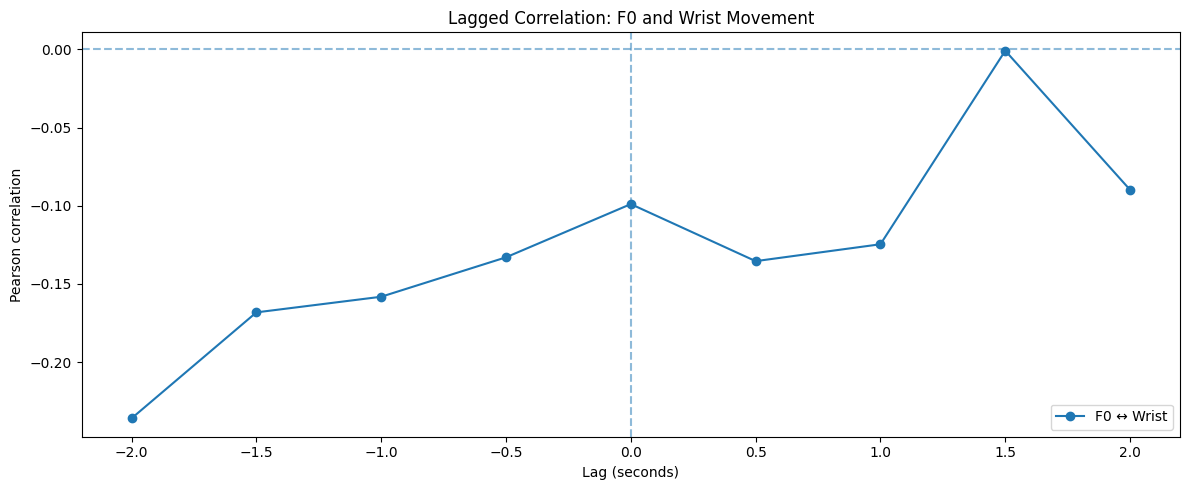

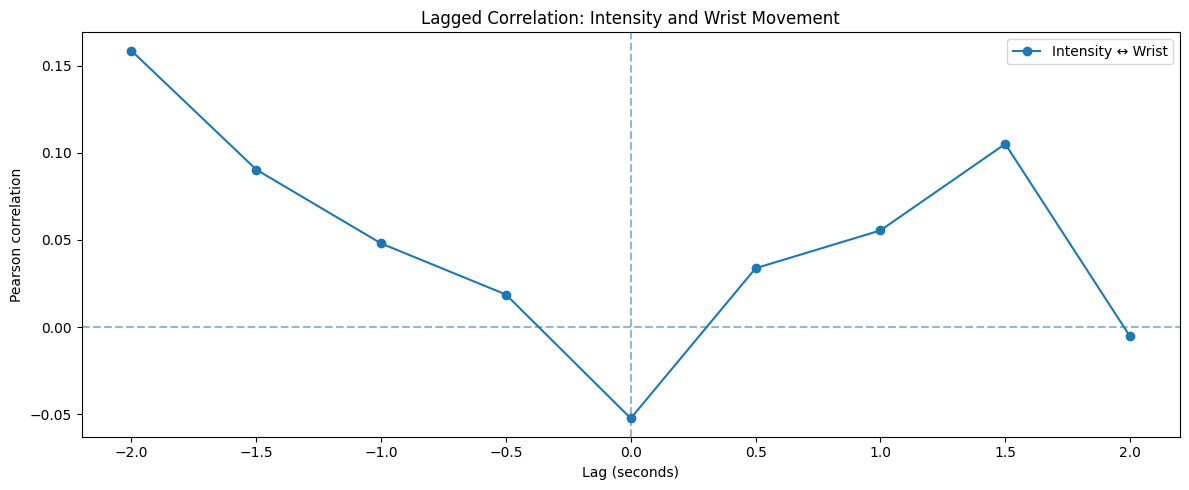


7.2 LAG ANALYSIS COMPLETE


In [46]:
# 7.2 Cross-Correlation / Lag Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr

print("===================================")
print("7.2 CROSS-CORRELATION / LAG ANALYSIS")
print("===================================")


# 1. Define lag range
#    Each temporal window = 0.5 seconds

window_size = 0.5

lag_steps = range(-4, 5)
lag_seconds = [
    step * window_size
    for step in lag_steps
]

print("Lag range:")
print(
    f"{lag_seconds[0]} s "
    f"to "
    f"{lag_seconds[-1]} s"
)


# 2. Function for lagged correlation

def calculate_lag_correlation(
    x,
    y,
    lag_steps
):

    results = []

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    for lag in lag_steps:

        # ----------------------------------------------------
        # Positive lag:
        # x occurs first, y follows later
        # ----------------------------------------------------

        if lag > 0:

            x_lag = x[:-lag]
            y_lag = y[lag:]

        # ----------------------------------------------------
        # Negative lag:
        # y occurs first, x follows later
        # ----------------------------------------------------

        elif lag < 0:

            x_lag = x[-lag:]
            y_lag = y[:lag]

        # ----------------------------------------------------
        # Zero lag
        # ----------------------------------------------------

        else:

            x_lag = x
            y_lag = y


        # ----------------------------------------------------
        # Remove invalid values pairwise
        # ----------------------------------------------------

        valid = (
            np.isfinite(x_lag) &
            np.isfinite(y_lag)
        )

        x_valid = x_lag[valid]
        y_valid = y_lag[valid]


        # ----------------------------------------------------
        # Calculate correlations
        # ----------------------------------------------------

        if len(x_valid) >= 3:

            pearson_r, pearson_p = pearsonr(
                x_valid,
                y_valid
            )

            spearman_rho, spearman_p = spearmanr(
                x_valid,
                y_valid
            )

        else:

            pearson_r = np.nan
            pearson_p = np.nan
            spearman_rho = np.nan
            spearman_p = np.nan


        results.append({

            "lag_steps": lag,
            "lag_seconds": lag * window_size,
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_rho": spearman_rho,
            "spearman_p": spearman_p,
            "valid_windows": len(x_valid)

        })


    return pd.DataFrame(results)


# 3. F0 ↔ Wrist Movement

f0_lag_df = calculate_lag_correlation(
    temporal_df["f0_mean"],
    temporal_df["wrist_mean_speed"],
    lag_steps
)

print("\n-----------------------------------")
print("F0 ↔ Wrist Movement")
print("-----------------------------------")

display(f0_lag_df)


# 4. Find strongest F0 lag

valid_f0 = f0_lag_df.dropna(
    subset=["pearson_r"]
).copy()

if len(valid_f0) > 0:

    best_f0 = valid_f0.loc[
        valid_f0["pearson_r"].abs().idxmax()
    ]

    print("Best Pearson lag for F0:")
    print(
        f"Lag: {best_f0['lag_seconds']} seconds"
    )
    print(
        f"Pearson r: {best_f0['pearson_r']}"
    )


# 5. Intensity ↔ Wrist Movement

intensity_lag_df = calculate_lag_correlation(
    temporal_df["intensity_mean"],
    temporal_df["wrist_mean_speed"],
    lag_steps
)

print("\n-----------------------------------")
print("Intensity ↔ Wrist Movement")
print("-----------------------------------")

display(intensity_lag_df)


# 6. Find strongest Intensity lag

valid_intensity = intensity_lag_df.dropna(
    subset=["pearson_r"]
).copy()

if len(valid_intensity) > 0:

    best_intensity = valid_intensity.loc[
        valid_intensity["pearson_r"].abs().idxmax()
    ]

    print("Best Pearson lag for Intensity:")
    print(
        f"Lag: {best_intensity['lag_seconds']} seconds"
    )
    print(
        f"Pearson r: {best_intensity['pearson_r']}"
    )


# 7. Plot F0 lag correlation

plt.figure(figsize=(12, 5))

plt.plot(
    f0_lag_df["lag_seconds"],
    f0_lag_df["pearson_r"],
    marker="o",
    label="F0 ↔ Wrist"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Lag (seconds)")
plt.ylabel("Pearson correlation")
plt.title(
    "Lagged Correlation: F0 and Wrist Movement"
)

plt.legend()
plt.tight_layout()
plt.show()


# 8. Plot Intensity lag correlation

plt.figure(figsize=(12, 5))

plt.plot(
    intensity_lag_df["lag_seconds"],
    intensity_lag_df["pearson_r"],
    marker="o",
    label="Intensity ↔ Wrist"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Lag (seconds)")
plt.ylabel("Pearson correlation")
plt.title(
    "Lagged Correlation: Intensity and Wrist Movement"
)

plt.legend()
plt.tight_layout()
plt.show()


print("\n===================================")
print("7.2 LAG ANALYSIS COMPLETE")
print("===================================")

7.3 EXTENDED LAG ANALYSIS
Lag range: -4.0 s to 4.0 s

-----------------------------------
F0 ↔ Wrist Movement
-----------------------------------


,lag_steps,lag_seconds,pearson_r,pearson_p,spearman_rho,spearman_p,valid_windows
0,-8,-4.0,-0.149416,0.200741,-0.031664,0.787404,75
1,-7,-3.5,-0.183949,0.111687,-0.198633,0.085409,76
2,-6,-3.0,-0.063626,0.582497,-0.259583,0.022619,77
3,-5,-2.5,-0.181884,0.110993,-0.182438,0.109891,78
4,-4,-2.0,-0.235961,0.036305,-0.321154,0.003904,79
5,-3,-1.5,-0.168207,0.135841,-0.285513,0.010253,80
6,-2,-1.0,-0.158209,0.158348,-0.228410,0.040273,81
7,-1,-0.5,-0.132995,0.233601,-0.314352,0.004025,82
8,0,0.0,-0.098969,0.376360,-0.241519,0.028820,82
9,1,0.5,-0.135446,0.225020,-0.157454,0.157731,82



-----------------------------------
Intensity ↔ Wrist Movement
-----------------------------------


,lag_steps,lag_seconds,pearson_r,pearson_p,spearman_rho,spearman_p,valid_windows
0,-8,-4.0,0.125088,0.180927,0.200062,0.031302,116
1,-7,-3.5,0.220111,0.017096,0.189723,0.040484,117
2,-6,-3.0,0.196589,0.032873,0.128402,0.165838,118
3,-5,-2.5,-0.005811,0.949989,0.038278,0.679381,119
4,-4,-2.0,0.158593,0.083616,-0.008195,0.929214,120
5,-3,-1.5,0.090355,0.324325,0.010182,0.911745,121
6,-2,-1.0,0.047981,0.599713,0.096712,0.289279,122
7,-1,-0.5,0.018663,0.837664,0.027473,0.762930,123
8,0,0.0,-0.052408,0.563209,0.002681,0.976421,124
9,1,0.5,0.033740,0.711023,0.025229,0.781791,123



Best F0 lag:
Lag: -2.0 seconds
Pearson r: -0.23596075052896998

Best Intensity lag:
Lag: 4.0 seconds
Pearson r: 0.23418953056518974


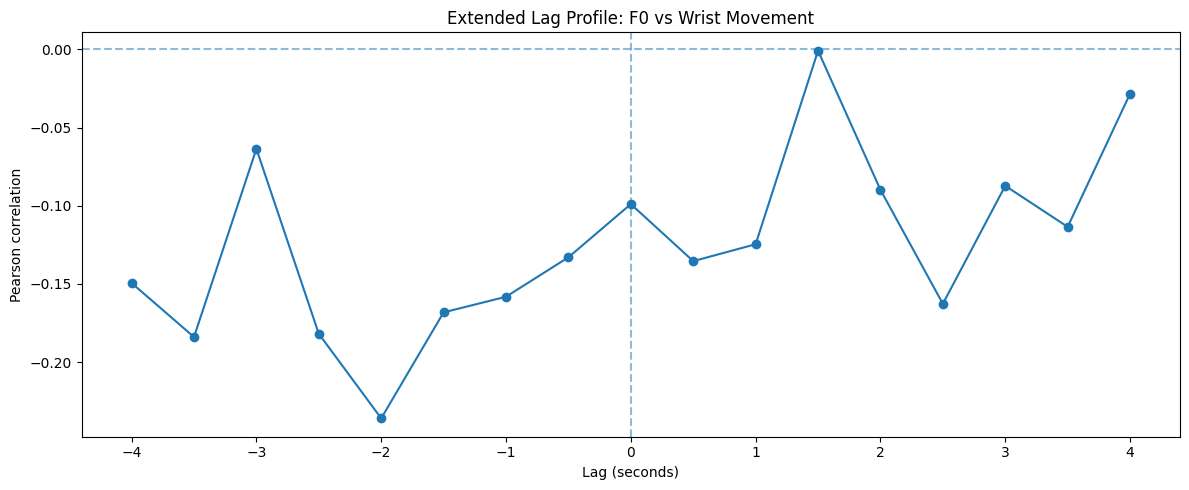

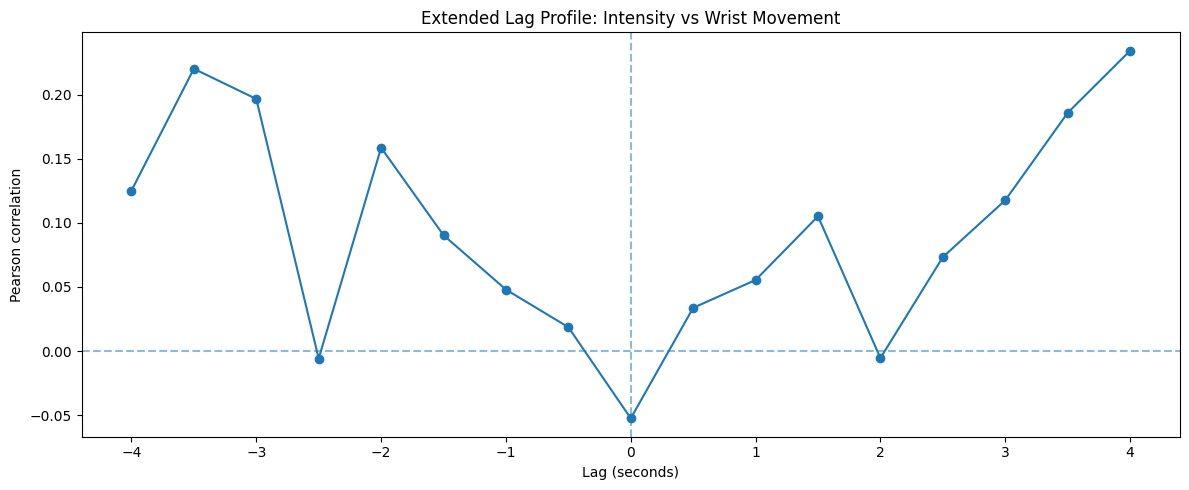


7.3 EXTENDED LAG ANALYSIS COMPLETE


In [47]:
# 7.3 Extended Lag Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("===================================")
print("7.3 EXTENDED LAG ANALYSIS")
print("===================================")


# 1. Extend lag range
#    Temporal resolution = 0.5 seconds

extended_lag_steps = range(-8, 9)

print(
    "Lag range:",
    min(extended_lag_steps) * 0.5,
    "s to",
    max(extended_lag_steps) * 0.5,
    "s"
)


# 2. F0 ↔ Wrist Movement

f0_extended_df = calculate_lag_correlation(
    temporal_df["f0_mean"],
    temporal_df["wrist_mean_speed"],
    extended_lag_steps
)

print("\n-----------------------------------")
print("F0 ↔ Wrist Movement")
print("-----------------------------------")

display(f0_extended_df)


# 3. Intensity ↔ Wrist Movement

intensity_extended_df = calculate_lag_correlation(
    temporal_df["intensity_mean"],
    temporal_df["wrist_mean_speed"],
    extended_lag_steps
)

print("\n-----------------------------------")
print("Intensity ↔ Wrist Movement")
print("-----------------------------------")

display(intensity_extended_df)


# 4. Find strongest F0 lag

valid_f0 = f0_extended_df.dropna(
    subset=["pearson_r"]
)

if len(valid_f0) > 0:

    best_f0 = valid_f0.loc[
        valid_f0["pearson_r"].abs().idxmax()
    ]

    print("\nBest F0 lag:")
    print("Lag:", best_f0["lag_seconds"], "seconds")
    print("Pearson r:", best_f0["pearson_r"])


# 5. Find strongest Intensity lag

valid_intensity = intensity_extended_df.dropna(
    subset=["pearson_r"]
)

if len(valid_intensity) > 0:

    best_intensity = valid_intensity.loc[
        valid_intensity["pearson_r"].abs().idxmax()
    ]

    print("\nBest Intensity lag:")
    print(
        "Lag:",
        best_intensity["lag_seconds"],
        "seconds"
    )

    print(
        "Pearson r:",
        best_intensity["pearson_r"]
    )


# 6. Plot F0 lag profile

plt.figure(figsize=(12, 5))

plt.plot(
    f0_extended_df["lag_seconds"],
    f0_extended_df["pearson_r"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Lag (seconds)")
plt.ylabel("Pearson correlation")
plt.title(
    "Extended Lag Profile: F0 vs Wrist Movement"
)

plt.tight_layout()
plt.show()


# 7. Plot Intensity lag profile

plt.figure(figsize=(12, 5))

plt.plot(
    intensity_extended_df["lag_seconds"],
    intensity_extended_df["pearson_r"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Lag (seconds)")
plt.ylabel("Pearson correlation")
plt.title(
    "Extended Lag Profile: Intensity vs Wrist Movement"
)

plt.tight_layout()
plt.show()


print("\n===================================")
print("7.3 EXTENDED LAG ANALYSIS COMPLETE")
print("===================================")

7.4 DETRENDED LAG ANALYSIS
Number of temporal windows: 124
Lag range: -4.0 s to 4.0 s

-----------------------------------
DE-TRENDED F0 ↔ WRIST MOVEMENT
-----------------------------------


,lag_steps,lag_seconds,pearson_r,pearson_p,spearman_rho,spearman_p,valid_windows
0,-8,-4.0,-0.147169,0.114913,-0.081936,0.381905,116
1,-7,-3.5,-0.169623,0.067501,-0.153074,0.099414,117
2,-6,-3.0,-0.083652,0.367803,-0.248350,0.006694,118
3,-5,-2.5,-0.192448,0.036008,-0.249687,0.006172,119
4,-4,-2.0,-0.231991,0.010784,-0.264539,0.003503,120
5,-3,-1.5,-0.216390,0.017130,-0.264219,0.003406,121
6,-2,-1.0,-0.194378,0.031923,-0.228837,0.011235,122
7,-1,-0.5,-0.189702,0.035594,-0.310721,0.000469,123
8,0,0.0,-0.177387,0.048730,-0.265183,0.002915,124
9,1,0.5,-0.156027,0.084831,-0.164534,0.068979,123



-----------------------------------
DE-TRENDED INTENSITY ↔ WRIST MOVEMENT
-----------------------------------


,lag_steps,lag_seconds,pearson_r,pearson_p,spearman_rho,spearman_p,valid_windows
0,-8,-4.0,0.101949,0.276164,0.163495,0.079491,116
1,-7,-3.5,0.197284,0.033004,0.165745,0.074110,117
2,-6,-3.0,0.172206,0.062227,0.112487,0.225220,118
3,-5,-2.5,-0.036279,0.695275,0.021286,0.818263,119
4,-4,-2.0,0.131388,0.152593,0.007125,0.938433,120
5,-3,-1.5,0.064970,0.478946,0.005006,0.956540,121
6,-2,-1.0,0.037965,0.678015,0.101701,0.264997,122
7,-1,-0.5,0.007763,0.932086,0.027221,0.765037,123
8,0,0.0,-0.064808,0.474538,-0.007383,0.935137,124
9,1,0.5,0.023408,0.797184,0.019270,0.832459,123



Best detrended F0 lag:
Lag: -2.0 seconds
Pearson r: -0.23199101293174668

Best detrended Intensity lag:
Lag: 4.0 seconds
Pearson r: 0.25461815630727097


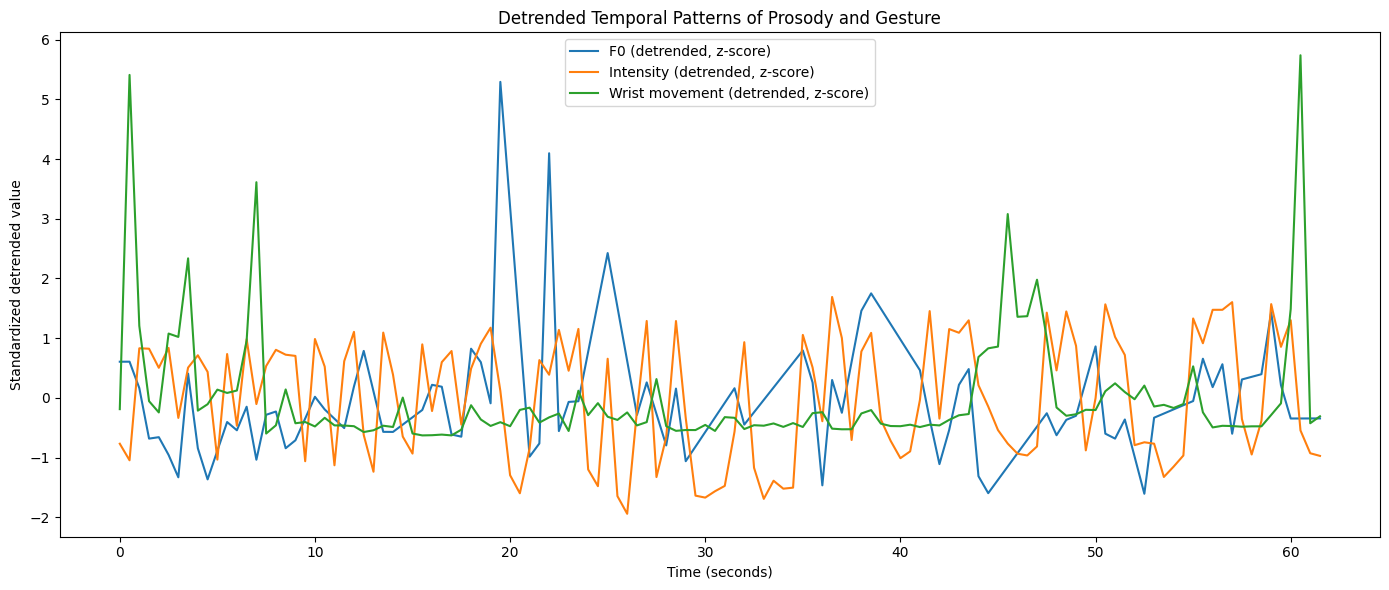

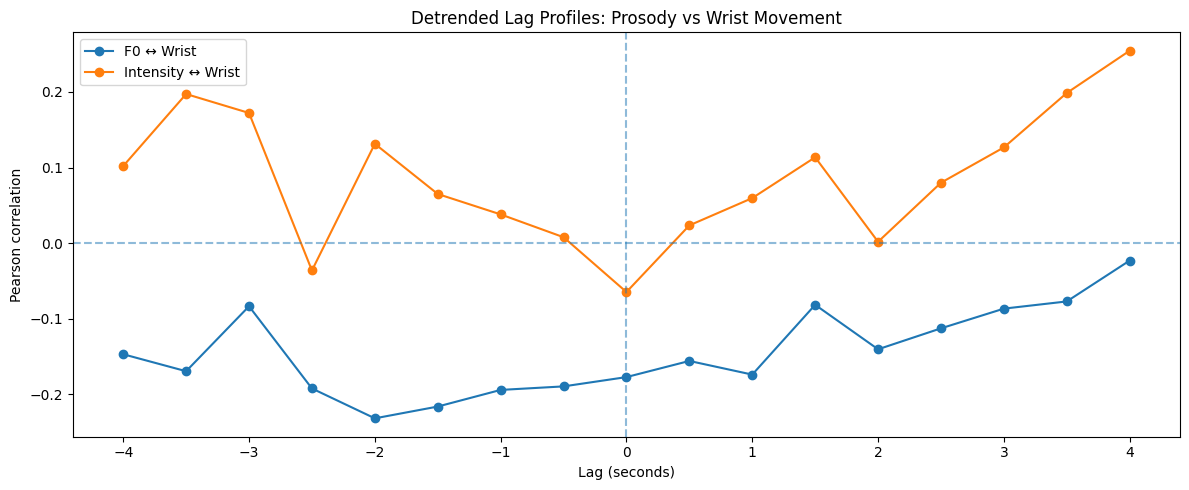


7.4 DETRENDED LAG ANALYSIS COMPLETE


In [48]:
# 7.4 Detrended Lag Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import detrend
from scipy.stats import pearsonr, spearmanr

print("===================================")
print("7.4 DETRENDED LAG ANALYSIS")
print("===================================")


# 1. Prepare temporal signals

analysis_df = temporal_df.copy()

window_size = 0.5

# Time axis
time = np.arange(len(analysis_df)) * window_size


# 2. Handle missing F0 values
#    Only for this exploratory time-series analysis

analysis_df["f0_analysis"] = (
    analysis_df["f0_mean"]
    .interpolate(method="linear")
    .bfill()
    .ffill()
)


# 3. Extract raw signals

f0_raw = analysis_df["f0_analysis"].to_numpy(dtype=float)
intensity_raw = analysis_df["intensity_mean"].to_numpy(dtype=float)
wrist_raw = analysis_df["wrist_mean_speed"].to_numpy(dtype=float)


# 4. Remove slow linear trends

f0_detrended = detrend(f0_raw)
intensity_detrended = detrend(intensity_raw)
wrist_detrended = detrend(wrist_raw)


# 5. Standardize signals

def zscore_signal(signal):

    std = np.std(signal)

    if std == 0:
        return np.zeros_like(signal)

    return (signal - np.mean(signal)) / std


f0_z = zscore_signal(f0_detrended)
intensity_z = zscore_signal(intensity_detrended)
wrist_z = zscore_signal(wrist_detrended)


# 6. Create detrended analysis dataframe

detrended_df = pd.DataFrame({
    "start": analysis_df["start"],
    "end": analysis_df["end"],
    "f0_detrended": f0_z,
    "intensity_detrended": intensity_z,
    "wrist_detrended": wrist_z
})

print("Number of temporal windows:", len(detrended_df))


# 7. Define lag range

lag_steps = range(-8, 9)

print(
    "Lag range:",
    min(lag_steps) * window_size,
    "s to",
    max(lag_steps) * window_size,
    "s"
)


# 8. Detrended F0 ↔ Wrist correlation

f0_detrended_lag_df = calculate_lag_correlation(
    f0_z,
    wrist_z,
    lag_steps
)

print("\n-----------------------------------")
print("DE-TRENDED F0 ↔ WRIST MOVEMENT")
print("-----------------------------------")

display(f0_detrended_lag_df)


# 9. Detrended Intensity ↔ Wrist correlation

intensity_detrended_lag_df = calculate_lag_correlation(
    intensity_z,
    wrist_z,
    lag_steps
)

print("\n-----------------------------------")
print("DE-TRENDED INTENSITY ↔ WRIST MOVEMENT")
print("-----------------------------------")

display(intensity_detrended_lag_df)


# 10. Find strongest F0 lag

valid_f0 = f0_detrended_lag_df.dropna(
    subset=["pearson_r"]
)

if len(valid_f0) > 0:

    best_f0_detrended = valid_f0.loc[
        valid_f0["pearson_r"].abs().idxmax()
    ]

    print("\nBest detrended F0 lag:")
    print(
        "Lag:",
        best_f0_detrended["lag_seconds"],
        "seconds"
    )

    print(
        "Pearson r:",
        best_f0_detrended["pearson_r"]
    )


# 11. Find strongest Intensity lag

valid_intensity = intensity_detrended_lag_df.dropna(
    subset=["pearson_r"]
)

if len(valid_intensity) > 0:

    best_intensity_detrended = valid_intensity.loc[
        valid_intensity["pearson_r"].abs().idxmax()
    ]

    print("\nBest detrended Intensity lag:")
    print(
        "Lag:",
        best_intensity_detrended["lag_seconds"],
        "seconds"
    )

    print(
        "Pearson r:",
        best_intensity_detrended["pearson_r"]
    )


# 12. Visualize detrended signals

plt.figure(figsize=(14, 6))

plt.plot(
    time,
    f0_z,
    label="F0 (detrended, z-score)"
)

plt.plot(
    time,
    intensity_z,
    label="Intensity (detrended, z-score)"
)

plt.plot(
    time,
    wrist_z,
    label="Wrist movement (detrended, z-score)"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Standardized detrended value")

plt.title(
    "Detrended Temporal Patterns of Prosody and Gesture"
)

plt.legend()
plt.tight_layout()
plt.show()


# 13. Plot lag profiles

plt.figure(figsize=(12, 5))

plt.plot(
    f0_detrended_lag_df["lag_seconds"],
    f0_detrended_lag_df["pearson_r"],
    marker="o",
    label="F0 ↔ Wrist"
)

plt.plot(
    intensity_detrended_lag_df["lag_seconds"],
    intensity_detrended_lag_df["pearson_r"],
    marker="o",
    label="Intensity ↔ Wrist"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Lag (seconds)")
plt.ylabel("Pearson correlation")

plt.title(
    "Detrended Lag Profiles: Prosody vs Wrist Movement"
)

plt.legend()
plt.tight_layout()
plt.show()


print("\n===================================")
print("7.4 DETRENDED LAG ANALYSIS COMPLETE")
print("===================================")

7.5 EVENT / PEAK-BASED COORDINATION
-----------------------------------
Detected events
-----------------------------------
F0 peaks: 20
Wrist movement peaks: 11

F0 events:


,event_id,time,value
0,0,3.5,0.407116
1,1,6.5,-0.147717
2,2,8.0,-0.228116
3,3,10.0,0.018869
4,4,12.5,0.787088
5,5,16.0,0.218981
6,6,18.0,0.823979
7,7,19.5,5.293112
8,8,22.0,4.097536
9,9,25.0,2.426253



Wrist events:


,event_id,time,value
0,0,0.5,5.409524
1,1,3.5,2.337319
2,2,7.0,3.612647
3,3,8.5,0.141585
4,4,14.5,0.005590
5,5,23.5,0.120444
6,6,27.5,0.315401
7,7,45.5,3.079243
8,8,47.0,1.979605
9,9,55.0,0.528691



-----------------------------------
F0–Wrist event matching
-----------------------------------
F0 peaks with a wrist peak within 2.0 seconds: 13


,f0_time,wrist_time,lag_seconds,absolute_lag
0,3.5,3.5,0.0,0.0
1,6.5,7.0,0.5,0.5
2,8.0,8.5,0.5,0.5
3,10.0,8.5,-1.5,1.5
4,12.5,14.5,2.0,2.0
5,16.0,14.5,-1.5,1.5
8,22.0,23.5,1.5,1.5
9,25.0,23.5,-1.5,1.5
10,27.0,27.5,0.5,0.5
11,28.5,27.5,-1.0,1.0


-----------------------------------
Event timing summary
-----------------------------------
Mean lag: 0.19230769230769232 seconds
Median lag: 0.5 seconds
Mean absolute lag: 1.1153846153846154 seconds
Median absolute lag: 1.5 seconds
Gesture-leading events: 5
Approximately simultaneous: 1
F0-leading events: 7


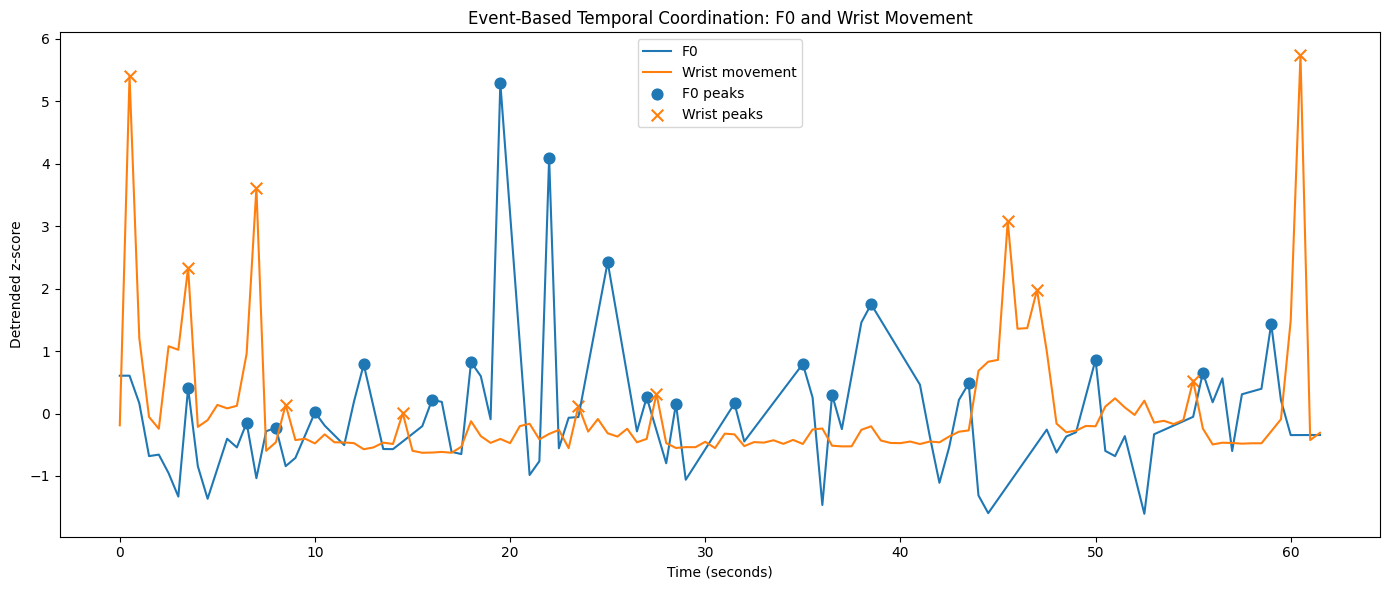

7.5 EVENT ANALYSIS COMPLETE


In [49]:
# 7.5 Event / Peak-Based Coordination Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

print("===================================")
print("7.5 EVENT / PEAK-BASED COORDINATION")
print("===================================")


# 1. Use detrended, standardized signals from 7.4

time = np.arange(len(detrended_df)) * window_size

f0_signal = detrended_df["f0_detrended"].to_numpy(dtype=float)
wrist_signal = detrended_df["wrist_detrended"].to_numpy(dtype=float)


# 2. Detect local peaks
#
# prominence = how strong a peak must be
# distance = minimum distance between peaks

f0_peaks, f0_properties = find_peaks(
    f0_signal,
    prominence=0.5,
    distance=2
)

wrist_peaks, wrist_properties = find_peaks(
    wrist_signal,
    prominence=0.5,
    distance=2
)


# 3. Create event tables

f0_events = pd.DataFrame({
    "event_id": range(len(f0_peaks)),
    "time": time[f0_peaks],
    "value": f0_signal[f0_peaks]
})

wrist_events = pd.DataFrame({
    "event_id": range(len(wrist_peaks)),
    "time": time[wrist_peaks],
    "value": wrist_signal[wrist_peaks]
})


print("-----------------------------------")
print("Detected events")
print("-----------------------------------")

print("F0 peaks:", len(f0_events))
print("Wrist movement peaks:", len(wrist_events))

print("\nF0 events:")
display(f0_events)

print("\nWrist events:")
display(wrist_events)


# 4. Match each F0 peak with nearest wrist peak

matches = []

for _, f0_event in f0_events.iterrows():

    if len(wrist_events) == 0:
        continue

    time_difference = (
        wrist_events["time"].to_numpy()
        - f0_event["time"]
    )

    nearest_index = np.argmin(
        np.abs(time_difference)
    )

    nearest_wrist_time = (
        wrist_events.iloc[nearest_index]["time"]
    )

    lag = nearest_wrist_time - f0_event["time"]

    matches.append({
        "f0_time": f0_event["time"],
        "wrist_time": nearest_wrist_time,
        "lag_seconds": lag,
        "absolute_lag": abs(lag)
    })


matches_df = pd.DataFrame(matches)


# 5. Restrict to reasonably close events

max_matching_lag = 2.0

if len(matches_df) > 0:

    matched_events_df = matches_df[
        matches_df["absolute_lag"] <= max_matching_lag
    ].copy()

else:

    matched_events_df = pd.DataFrame(
        columns=[
            "f0_time",
            "wrist_time",
            "lag_seconds",
            "absolute_lag"
        ]
    )


print("\n-----------------------------------")
print("F0–Wrist event matching")
print("-----------------------------------")

print(
    "F0 peaks with a wrist peak within",
    max_matching_lag,
    "seconds:",
    len(matched_events_df)
)

display(matched_events_df)


# 6. Summarize event timing

if len(matched_events_df) > 0:

    print("-----------------------------------")
    print("Event timing summary")
    print("-----------------------------------")

    print(
        "Mean lag:",
        matched_events_df["lag_seconds"].mean(),
        "seconds"
    )

    print(
        "Median lag:",
        matched_events_df["lag_seconds"].median(),
        "seconds"
    )

    print(
        "Mean absolute lag:",
        matched_events_df["absolute_lag"].mean(),
        "seconds"
    )

    print(
        "Median absolute lag:",
        matched_events_df["absolute_lag"].median(),
        "seconds"
    )

    print(
        "Gesture-leading events:",
        (matched_events_df["lag_seconds"] < 0).sum()
    )

    print(
        "Approximately simultaneous:",
        (matched_events_df["lag_seconds"] == 0).sum()
    )

    print(
        "F0-leading events:",
        (matched_events_df["lag_seconds"] > 0).sum()
    )

else:

    print("No matched events found.")


# 7. Visualize detected events

plt.figure(figsize=(14, 6))

plt.plot(
    time,
    f0_signal,
    label="F0"
)

plt.plot(
    time,
    wrist_signal,
    label="Wrist movement"
)

plt.scatter(
    time[f0_peaks],
    f0_signal[f0_peaks],
    marker="o",
    s=60,
    label="F0 peaks"
)

plt.scatter(
    time[wrist_peaks],
    wrist_signal[wrist_peaks],
    marker="x",
    s=70,
    label="Wrist peaks"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Detrended z-score")

plt.title(
    "Event-Based Temporal Coordination: F0 and Wrist Movement"
)

plt.legend()
plt.tight_layout()
plt.show()


print("===================================")
print("7.5 EVENT ANALYSIS COMPLETE")
print("===================================")

7.6 ONE-TO-ONE EVENT MATCHING
-----------------------------------
ONE-TO-ONE EVENT MATCHING
-----------------------------------
F0 peaks: 20
Wrist peaks: 11
One-to-one matched events: 9


,f0_id,wrist_id,f0_time,wrist_time,lag_seconds,absolute_lag
0,0.0,1.0,3.5,3.5,0.0,0.0
1,1.0,2.0,6.5,7.0,0.5,0.5
2,2.0,3.0,8.0,8.5,0.5,0.5
3,10.0,6.0,27.0,27.5,0.5,0.5
4,18.0,9.0,55.5,55.0,-0.5,0.5
7,5.0,4.0,16.0,14.5,-1.5,1.5
8,8.0,5.0,22.0,23.5,1.5,1.5
9,19.0,10.0,59.0,60.5,1.5,1.5
14,16.0,7.0,43.5,45.5,2.0,2.0


-----------------------------------
ONE-TO-ONE TIMING SUMMARY
-----------------------------------
Mean lag: 0.5 seconds
Median lag: 0.5 seconds
Mean absolute lag: 0.9444444444444444 seconds
Median absolute lag: 0.5 seconds
Gesture-leading: 2
Simultaneous: 1
F0-leading: 6


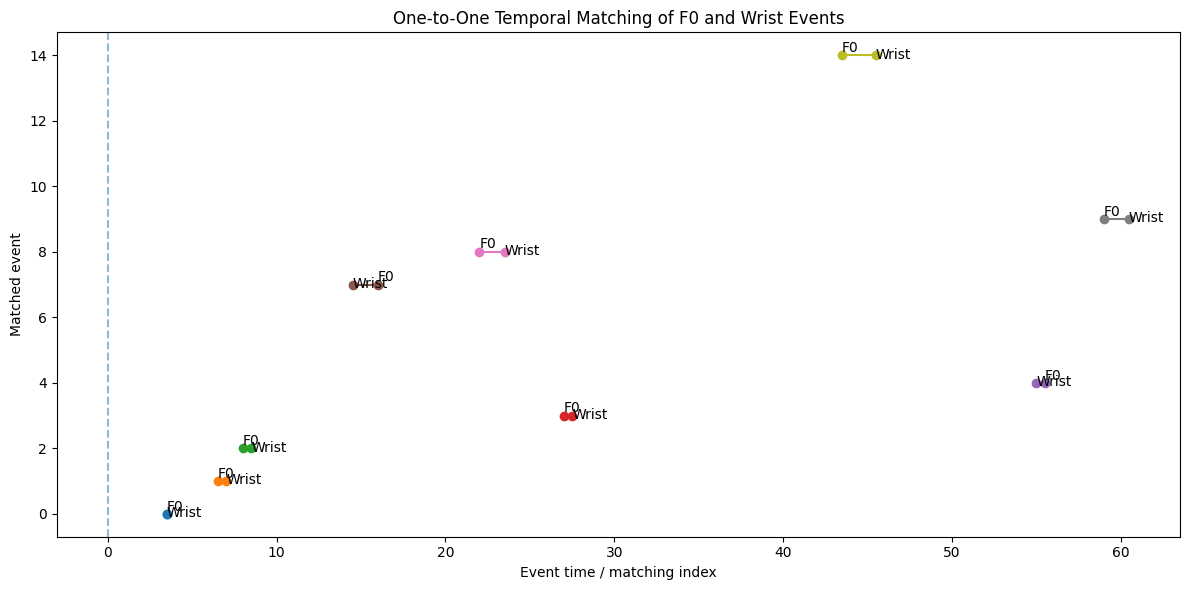


7.6 ONE-TO-ONE MATCHING COMPLETE


In [50]:
# 7.6 One-to-One Event Matching

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("===================================")
print("7.6 ONE-TO-ONE EVENT MATCHING")
print("===================================")


# 1. Prepare event times

f0_times = f0_events["time"].to_numpy(dtype=float)
wrist_times = wrist_events["time"].to_numpy(dtype=float)

max_matching_lag = 2.0


# 2. Create all possible F0–wrist pairs

candidate_pairs = []

for f0_id, f0_time in enumerate(f0_times):

    for wrist_id, wrist_time in enumerate(wrist_times):

        lag = wrist_time - f0_time
        absolute_lag = abs(lag)

        if absolute_lag <= max_matching_lag:

            candidate_pairs.append({
                "f0_id": f0_id,
                "wrist_id": wrist_id,
                "f0_time": f0_time,
                "wrist_time": wrist_time,
                "lag_seconds": lag,
                "absolute_lag": absolute_lag
            })


candidate_pairs_df = pd.DataFrame(candidate_pairs)


# 3. Greedy one-to-one matching
#    Match closest events first

if len(candidate_pairs_df) > 0:

    candidate_pairs_df = candidate_pairs_df.sort_values(
        "absolute_lag"
    ).reset_index(drop=True)

    used_f0 = set()
    used_wrist = set()

    one_to_one_matches = []

    for _, pair in candidate_pairs_df.iterrows():

        f0_id = int(pair["f0_id"])
        wrist_id = int(pair["wrist_id"])

        if f0_id in used_f0:
            continue

        if wrist_id in used_wrist:
            continue

        one_to_one_matches.append(pair)

        used_f0.add(f0_id)
        used_wrist.add(wrist_id)


    matched_1to1_df = pd.DataFrame(
        one_to_one_matches
    )

else:

    matched_1to1_df = pd.DataFrame(
        columns=[
            "f0_id",
            "wrist_id",
            "f0_time",
            "wrist_time",
            "lag_seconds",
            "absolute_lag"
        ]
    )


# 4. Display one-to-one matches

print("-----------------------------------")
print("ONE-TO-ONE EVENT MATCHING")
print("-----------------------------------")

print(
    "F0 peaks:",
    len(f0_events)
)

print(
    "Wrist peaks:",
    len(wrist_events)
)

print(
    "One-to-one matched events:",
    len(matched_1to1_df)
)

display(matched_1to1_df)


# 5. Timing summary

if len(matched_1to1_df) > 0:

    mean_lag = matched_1to1_df[
        "lag_seconds"
    ].mean()

    median_lag = matched_1to1_df[
        "lag_seconds"
    ].median()

    mean_absolute_lag = matched_1to1_df[
        "absolute_lag"
    ].mean()

    median_absolute_lag = matched_1to1_df[
        "absolute_lag"
    ].median()

    gesture_leading = (
        matched_1to1_df["lag_seconds"] < 0
    ).sum()

    simultaneous = (
        matched_1to1_df["lag_seconds"] == 0
    ).sum()

    f0_leading = (
        matched_1to1_df["lag_seconds"] > 0
    ).sum()

    print("-----------------------------------")
    print("ONE-TO-ONE TIMING SUMMARY")
    print("-----------------------------------")

    print("Mean lag:", mean_lag, "seconds")
    print("Median lag:", median_lag, "seconds")

    print(
        "Mean absolute lag:",
        mean_absolute_lag,
        "seconds"
    )

    print(
        "Median absolute lag:",
        median_absolute_lag,
        "seconds"
    )

    print(
        "Gesture-leading:",
        gesture_leading
    )

    print(
        "Simultaneous:",
        simultaneous
    )

    print(
        "F0-leading:",
        f0_leading
    )


# 6. Plot event timing

plt.figure(figsize=(12, 6))

if len(matched_1to1_df) > 0:

    for i, row in matched_1to1_df.iterrows():

        plt.plot(
            [row["f0_time"], row["wrist_time"]],
            [i, i],
            marker="o"
        )

        plt.text(
            row["f0_time"],
            i + 0.1,
            "F0"
        )

        plt.text(
            row["wrist_time"],
            i - 0.1,
            "Wrist"
        )

plt.axvline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Event time / matching index")
plt.ylabel("Matched event")

plt.title(
    "One-to-One Temporal Matching of F0 and Wrist Events"
)

plt.tight_layout()
plt.show()


print("\n===================================")
print("7.6 ONE-TO-ONE MATCHING COMPLETE")
print("===================================")

7.7 TEMPORAL COORDINATION VISUALIZATION


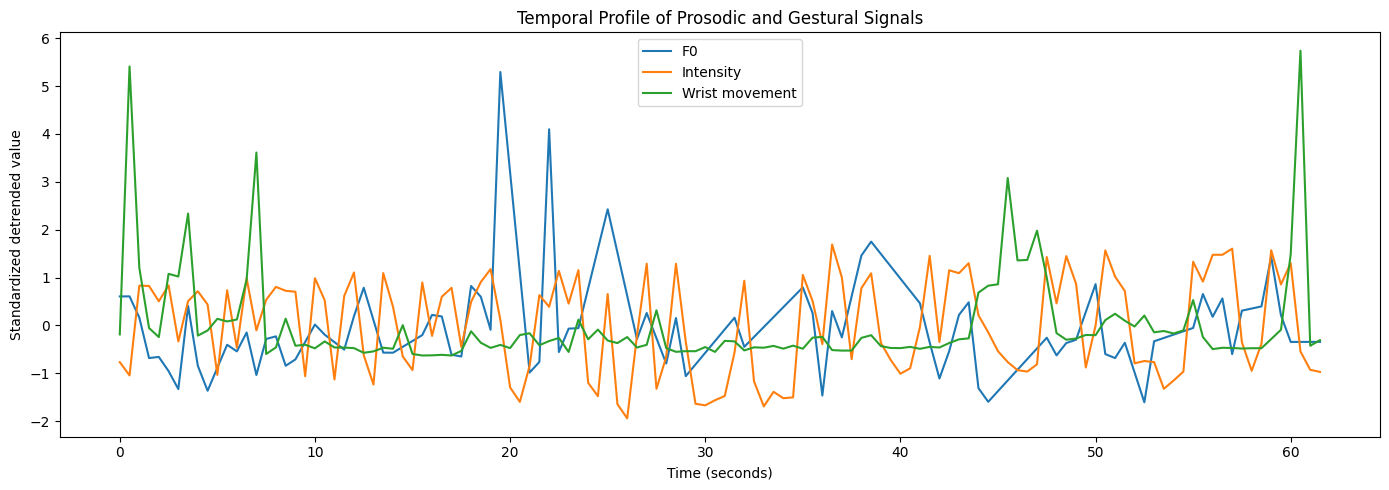

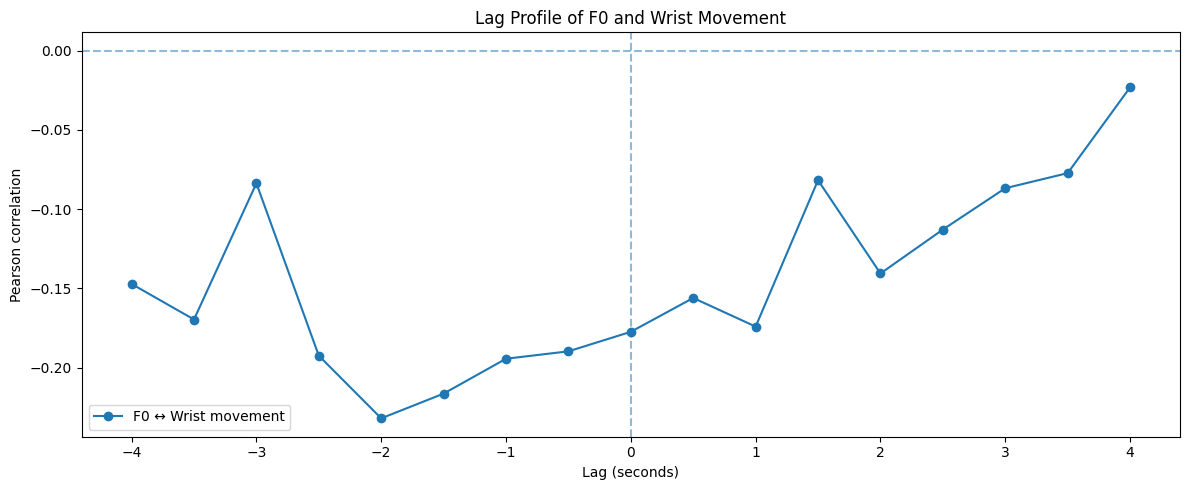

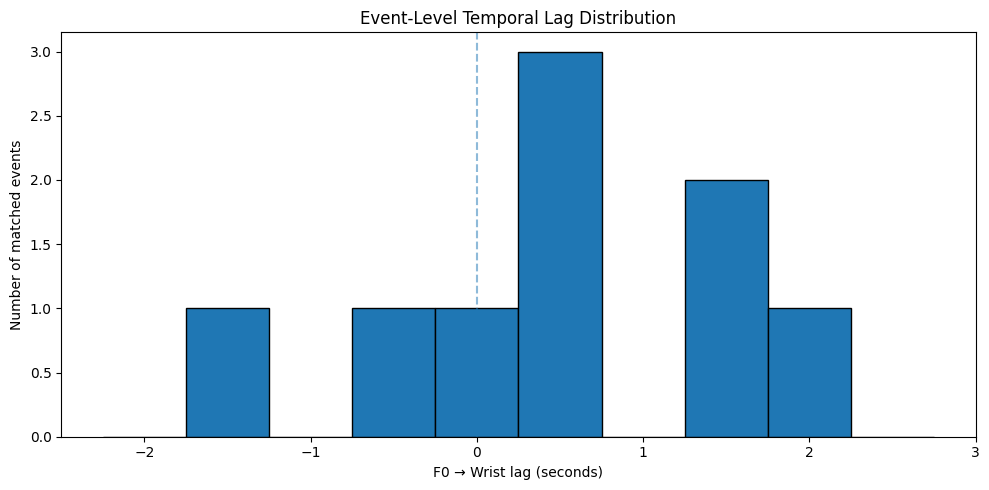

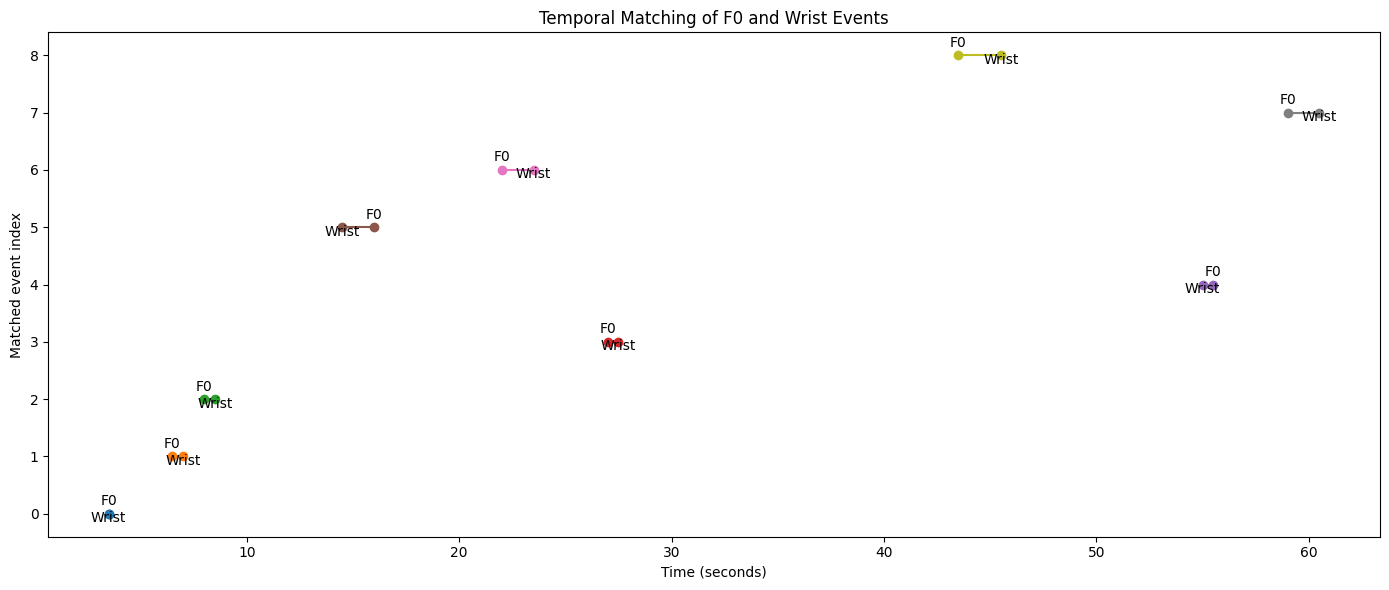


TEMPORAL COORDINATION SUMMARY
Number of temporal windows: 124
Temporal resolution: 0.5 seconds
Number of F0 peaks: 20
Number of wrist movement peaks: 11
Number of one-to-one matched events: 9
Mean event lag: 0.5 seconds
Median event lag: 0.5 seconds
Mean absolute event lag: 0.9444444444444444 seconds
Median absolute event lag: 0.5 seconds
Gesture-leading events: 2
Simultaneous events: 1
F0-leading events: 6

7.7 VISUALIZATION COMPLETE


In [51]:
# 7.7 Temporal Coordination Visualization

import numpy as np
import matplotlib.pyplot as plt

print("===================================")
print("7.7 TEMPORAL COORDINATION VISUALIZATION")
print("===================================")


# 1. Prepare temporal signals

time = np.arange(len(detrended_df)) * window_size

f0_signal = detrended_df["f0_detrended"].to_numpy(dtype=float)

intensity_signal = (
    detrended_df["intensity_detrended"]
    .to_numpy(dtype=float)
)

wrist_signal = (
    detrended_df["wrist_detrended"]
    .to_numpy(dtype=float)
)


# 2. Visualization A:
#    Temporal profile of multimodal signals

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    f0_signal,
    label="F0"
)

plt.plot(
    time,
    intensity_signal,
    label="Intensity"
)

plt.plot(
    time,
    wrist_signal,
    label="Wrist movement"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Standardized detrended value")

plt.title(
    "Temporal Profile of Prosodic and Gestural Signals"
)

plt.legend()

plt.tight_layout()
plt.show()


# 3. Visualization B:
#    Lag profile between F0 and wrist movement

plt.figure(figsize=(12, 5))

plt.plot(
    f0_detrended_lag_df["lag_seconds"],
    f0_detrended_lag_df["pearson_r"],
    marker="o",
    label="F0 ↔ Wrist movement"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Lag (seconds)")
plt.ylabel("Pearson correlation")

plt.title(
    "Lag Profile of F0 and Wrist Movement"
)

plt.legend()

plt.tight_layout()
plt.show()


# 4. Visualization C:
#    Event-level lag distribution

plt.figure(figsize=(10, 5))

if len(matched_1to1_df) > 0:

    bins = np.arange(
        -2.25,
        2.76,
        0.5
    )

    plt.hist(
        matched_1to1_df["lag_seconds"],
        bins=bins,
        edgecolor="black"
    )

plt.axvline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xlabel(
    "F0 → Wrist lag (seconds)"
)

plt.ylabel(
    "Number of matched events"
)

plt.title(
    "Event-Level Temporal Lag Distribution"
)

plt.tight_layout()
plt.show()


# 5. Visualization D:
#    Matched F0 and wrist events on the time axis

plt.figure(figsize=(14, 6))

if len(matched_1to1_df) > 0:

    for event_index, (_, row) in enumerate(
        matched_1to1_df.iterrows()
    ):

        # Connect F0 event and wrist event
        plt.plot(
            [row["f0_time"], row["wrist_time"]],
            [event_index, event_index],
            marker="o"
        )

        # F0 event
        plt.text(
            row["f0_time"],
            event_index + 0.15,
            "F0",
            ha="center"
        )

        # Wrist event
        plt.text(
            row["wrist_time"],
            event_index - 0.15,
            "Wrist",
            ha="center"
        )

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Matched event index"
)

plt.title(
    "Temporal Matching of F0 and Wrist Events"
)

plt.tight_layout()
plt.show()


# 6. Summary statistics

print("\n===================================")
print("TEMPORAL COORDINATION SUMMARY")
print("===================================")

print(
    "Number of temporal windows:",
    len(temporal_df)
)

print(
    "Temporal resolution:",
    window_size,
    "seconds"
)

print(
    "Number of F0 peaks:",
    len(f0_events)
)

print(
    "Number of wrist movement peaks:",
    len(wrist_events)
)

print(
    "Number of one-to-one matched events:",
    len(matched_1to1_df)
)


if len(matched_1to1_df) > 0:

    print(
        "Mean event lag:",
        matched_1to1_df["lag_seconds"].mean(),
        "seconds"
    )

    print(
        "Median event lag:",
        matched_1to1_df["lag_seconds"].median(),
        "seconds"
    )

    print(
        "Mean absolute event lag:",
        matched_1to1_df["absolute_lag"].mean(),
        "seconds"
    )

    print(
        "Median absolute event lag:",
        matched_1to1_df["absolute_lag"].median(),
        "seconds"
    )

    print(
        "Gesture-leading events:",
        (
            matched_1to1_df["lag_seconds"] < 0
        ).sum()
    )

    print(
        "Simultaneous events:",
        (
            matched_1to1_df["lag_seconds"] == 0
        ).sum()
    )

    print(
        "F0-leading events:",
        (
            matched_1to1_df["lag_seconds"] > 0
        ).sum()
    )


print("\n===================================")
print("7.7 VISUALIZATION COMPLETE")
print("===================================")

In [52]:
# 7.8 Research Findings Summary

print("===================================")
print("7.8 RESEARCH FINDINGS SUMMARY")
print("===================================")


# 1. Dataset information

num_windows = len(temporal_df)
num_f0_peaks = len(f0_events)
num_wrist_peaks = len(wrist_events)
num_matched_events = len(matched_1to1_df)


# 2. Overall correlation results

f0_pearson_r, f0_pearson_p = pearsonr(
    temporal_df.loc[
        np.isfinite(temporal_df["f0_mean"]) &
        np.isfinite(temporal_df["wrist_mean_speed"]),
        "f0_mean"
    ],
    temporal_df.loc[
        np.isfinite(temporal_df["f0_mean"]) &
        np.isfinite(temporal_df["wrist_mean_speed"]),
        "wrist_mean_speed"
    ]
)

intensity_pearson_r, intensity_pearson_p = pearsonr(
    temporal_df["intensity_mean"],
    temporal_df["wrist_mean_speed"]
)


# 3. Detrended lag results

best_f0_detrended = (
    f0_detrended_lag_df
    .dropna(subset=["pearson_r"])
    .loc[
        lambda df: df["pearson_r"].abs().idxmax()
    ]
)

best_intensity_detrended = (
    intensity_detrended_lag_df
    .dropna(subset=["pearson_r"])
    .loc[
        lambda df: df["pearson_r"].abs().idxmax()
    ]
)


# 4. Event-level results

if num_matched_events > 0:

    mean_event_lag = (
        matched_1to1_df["lag_seconds"].mean()
    )

    median_event_lag = (
        matched_1to1_df["lag_seconds"].median()
    )

    median_absolute_lag = (
        matched_1to1_df["absolute_lag"].median()
    )

    gesture_leading = (
        matched_1to1_df["lag_seconds"] < 0
    ).sum()

    simultaneous = (
        matched_1to1_df["lag_seconds"] == 0
    ).sum()

    f0_leading = (
        matched_1to1_df["lag_seconds"] > 0
    ).sum()

else:

    mean_event_lag = np.nan
    median_event_lag = np.nan
    median_absolute_lag = np.nan
    gesture_leading = 0
    simultaneous = 0
    f0_leading = 0


# 5. Print numerical summary

print("\n-----------------------------------")
print("Dataset")
print("-----------------------------------")

print(
    "Input: 1 spontaneous Chinese speech video"
)

print(
    "Temporal windows:",
    num_windows
)

print(
    "Temporal resolution:",
    window_size,
    "seconds"
)

print(
    "F0 peaks:",
    num_f0_peaks
)

print(
    "Wrist movement peaks:",
    num_wrist_peaks
)

print(
    "One-to-one matched events:",
    num_matched_events
)


print("\n-----------------------------------")
print("Correlation")
print("-----------------------------------")

print(
    "F0 ↔ Wrist Pearson r:",
    round(f0_pearson_r, 4)
)

print(
    "F0 ↔ Wrist Pearson p:",
    round(f0_pearson_p, 4)
)

print(
    "Intensity ↔ Wrist Pearson r:",
    round(intensity_pearson_r, 4)
)

print(
    "Intensity ↔ Wrist Pearson p:",
    round(intensity_pearson_p, 4)
)


print("\n-----------------------------------")
print("Detrended Lag Analysis")
print("-----------------------------------")

print(
    "Best F0 lag:",
    best_f0_detrended["lag_seconds"],
    "s"
)

print(
    "F0 lag Pearson r:",
    round(
        best_f0_detrended["pearson_r"],
        4
    )
)

print(
    "Best Intensity lag:",
    best_intensity_detrended["lag_seconds"],
    "s"
)

print(
    "Intensity lag Pearson r:",
    round(
        best_intensity_detrended["pearson_r"],
        4
    )
)


print("\n-----------------------------------")
print("Event-Level Coordination")
print("-----------------------------------")

print(
    "Mean event lag:",
    round(mean_event_lag, 4),
    "s"
)

print(
    "Median event lag:",
    round(median_event_lag, 4),
    "s"
)

print(
    "Median absolute lag:",
    round(median_absolute_lag, 4),
    "s"
)

print(
    "Gesture-leading events:",
    gesture_leading
)

print(
    "Simultaneous events:",
    simultaneous
)

print(
    "F0-leading events:",
    f0_leading
)


# 6. Generate a research-oriented interpretation

research_summary = f"""
Research Findings Summary
=========================

This notebook presents an end-to-end proof-of-concept pipeline for
multimodal analysis of spontaneous Chinese speech.

The pipeline integrates automatic speech recognition, prosodic
features (F0 and intensity), wrist movement, temporal alignment,
and exploratory temporal coordination analysis.

The current demonstration is based on one spontaneous Chinese
speech video and uses {num_windows} temporal windows with a
resolution of {window_size:.1f} seconds.

Exploratory correlation analysis showed a weak negative association
between F0 and wrist movement (Pearson r = {f0_pearson_r:.3f}),
whereas the association between intensity and wrist movement was
close to zero (Pearson r = {intensity_pearson_r:.3f}).

After detrending, the strongest F0–wrist correlation occurred at
a lag of {best_f0_detrended["lag_seconds"]:.1f} seconds
(Pearson r = {best_f0_detrended["pearson_r"]:.3f}).

The strongest detrended intensity–wrist correlation occurred at
a lag of {best_intensity_detrended["lag_seconds"]:.1f} seconds
(Pearson r = {best_intensity_detrended["pearson_r"]:.3f}).

Event-based analysis identified {num_matched_events} one-to-one
F0–wrist event matches. The median event lag was
{median_event_lag:.2f} seconds, with {gesture_leading}
gesture-leading events, {simultaneous} approximately simultaneous
events, and {f0_leading} F0-leading events.

These findings are exploratory and should not be interpreted as
evidence of a general temporal coordination effect. The current
single-video demonstration is intended to validate the multimodal
pipeline and motivate analysis on a larger, independently sampled
multimodal speech dataset.
"""


# 7. Display final research summary

print("\n===================================")
print("RESEARCH INTERPRETATION")
print("===================================")

print(research_summary)


# 8. Save summary to a text file

summary_file = "research_findings_summary.txt"

with open(
    summary_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(research_summary)


print("===================================")
print("7.8 SUMMARY COMPLETE")
print("===================================")

print(
    "Summary saved to:",
    summary_file
)

7.8 RESEARCH FINDINGS SUMMARY

-----------------------------------
Dataset
-----------------------------------
Input: 1 spontaneous Chinese speech video
Temporal windows: 124
Temporal resolution: 0.5 seconds
F0 peaks: 20
Wrist movement peaks: 11
One-to-one matched events: 9

-----------------------------------
Correlation
-----------------------------------
F0 ↔ Wrist Pearson r: -0.099
F0 ↔ Wrist Pearson p: 0.3764
Intensity ↔ Wrist Pearson r: -0.0524
Intensity ↔ Wrist Pearson p: 0.5632

-----------------------------------
Detrended Lag Analysis
-----------------------------------
Best F0 lag: -2.0 s
F0 lag Pearson r: -0.232
Best Intensity lag: 4.0 s
Intensity lag Pearson r: 0.2546

-----------------------------------
Event-Level Coordination
-----------------------------------
Mean event lag: 0.5 s
Median event lag: 0.5 s
Median absolute lag: 0.5 s
Gesture-leading events: 2
Simultaneous events: 1
F0-leading events: 6

RESEARCH INTERPRETATION

Research Findings Summary

This notebook pr